# Patch spread: JPEG zig-zag metrics

Отдельный ноутбук для анализа того, как spatial-дельта от патча расползается по карте слоя. Нумерация клеток — JPEG zig-zag: старт из левого верхнего угла, обход по антидиагоналям с чередованием направления. Это не row-wise snake, а порядок вида `(0,0) → (0,1) → (1,0) → (2,0) → (1,1) → (0,2) ...`.


In [1]:
from pathlib import Path
import sys

_nb_cwd = Path.cwd()
if (_nb_cwd / "new_experiments" / "patch_success_analysis").exists():
    sys.path.insert(0, str(_nb_cwd / "new_experiments"))
elif (_nb_cwd / "patch_success_analysis").exists():
    sys.path.insert(0, str(_nb_cwd))
else:
    raise RuntimeError(f"Unexpected cwd={_nb_cwd}; run from repo root or new_experiments")

import pandas as pd

from patch_success_analysis.notebook_setup import (
    ensure_new_experiments_cwd,
    load_segmentig_success_failure_rows,
    make_coco_people_patch_success_experiment,
    select_balanced_rows,
)

# Source cache: параметры большого уже сохраненного attack/sf cache.
source_pool_size = 7200
source_n_success = 3000
source_n_fail = 3000
analysis_examples_per_class = 3000

cwd = ensure_new_experiments_cwd()
attack_config, config, exp = make_coco_people_patch_success_experiment(
    pool_size=source_pool_size,
    n_success=source_n_success,
    n_fail=source_n_fail,
)
print(f"cwd={cwd}")
print(f"source attack cache key={attack_config.cache_key()}")
print(f"source attack cache path={attack_config.cache_path}")
cache = exp.build_or_load_cache(force=False)

force_success_failure_metrics_recompute = False
sf, rows_df_full, quality_df = load_segmentig_success_failure_rows(
    exp,
    force=force_success_failure_metrics_recompute,
)
rows_df = select_balanced_rows(rows_df_full, per_class=analysis_examples_per_class)
print(f"source examples={len(rows_df_full)}, skipped={len(sf.get('skipped', []))}, sf_loaded_from_cache={sf.get('loaded_from_cache')}")
print(
    f"analysis examples={len(rows_df)} "
    f"({int(rows_df['success'].sum())} success / {int((~rows_df['success'].astype(bool)).sum())} fail)"
)
print(sf.get("cache_path"))


cwd=/Users/ashentide/PycharmProjects/PatchSuccessResearch/new_experiments
source attack cache key=e91cdfc4a2c4e20d
source attack cache path=new_experiments/outputs/patch_success_analysis/cache/attack_pool_e91cdfc4a2c4e20d.pkl
source examples=5646, skipped=4, sf_loaded_from_cache=True
analysis examples=5292 (2646 success / 2646 fail)
new_experiments/outputs/patch_success_analysis/cache/segmentig_success_failure_metrics_3362be6645634ce2.pkl


In [2]:
import hashlib
import json
import pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from patch_success_analysis.activations import compute_layer_deltas
from patch_success_analysis.metrics import (
    delta_zigzag_profile,
    jpeg_zigzag_indices,
    metric_quality_rows,
    normalized_cumulative_auc,
    normalized_cumulative_curve,
)
from patch_success_analysis.plots import plot_metric_distribution_and_roc
from patch_success_analysis.notebook_setup import resolve_existing_path, select_balanced_rows

zigzag_layer_name = "model.22"
zigzag_examples_per_class = analysis_examples_per_class
zigzag_modes = ["mean_abs", "signed_mean"]
zigzag_rng = np.random.default_rng(31)

def _stack_profiles(values):
    min_len = min(len(v) for v in values)
    return np.stack([np.asarray(v[:min_len], dtype="float64") for v in values], axis=0)

def _profile_group_stats(records, mode):
    rows = []
    for success_value, label in [(True, "success"), (False, "fail")]:
        profiles = [item[f"profile_{mode}"] for item in records if bool(item["success"]) == success_value]
        stack = _stack_profiles(profiles)
        rows.append({
            "label": label,
            "success": success_value,
            "x": np.linspace(0.0, 1.0, stack.shape[1]),
            "mean": stack.mean(axis=0),
            "std": stack.std(axis=0),
        })
    return rows

def _cumulative_group_stats(records, mode):
    rows = []
    for success_value, label in [(True, "success"), (False, "fail")]:
        curves = []
        for item in records:
            if bool(item["success"]) != success_value:
                continue
            x, y = normalized_cumulative_curve(item[f"profile_{mode}"])
            curves.append(y)
        stack = _stack_profiles(curves)
        rows.append({
            "label": label,
            "success": success_value,
            "x": np.linspace(0.0, 1.0, stack.shape[1]),
            "mean": stack.mean(axis=0),
            "std": stack.std(axis=0),
        })
    return rows

def _plot_group_lines(stats, title, ylabel, *, with_std=False):
    fig, ax = plt.subplots(figsize=(11, 4.8), constrained_layout=True)
    colors = {"success": "#4C78A8", "fail": "#F58518"}
    for row in stats:
        color = colors[row["label"]]
        ax.plot(row["x"], row["mean"], label=row["label"], color=color)
        if with_std:
            ax.fill_between(row["x"], row["mean"] - row["std"], row["mean"] + row["std"], color=color, alpha=0.18)
    ax.set_title(title)
    ax.set_xlabel("normalized JPEG zig-zag cell index")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)
    ax.legend()
    plt.show()


### Patch spread по всем слоям на одной картинке

Берём один success-example и считаем clean/patched delta на всех display-слоях. Каналы схлопываем через `mean_abs`, затем разворачиваем spatial-карту в JPEG zig-zag profile. Это нужно как sanity check: видно, где по порядку карты концентрируется изменение от патча на разных слоях.


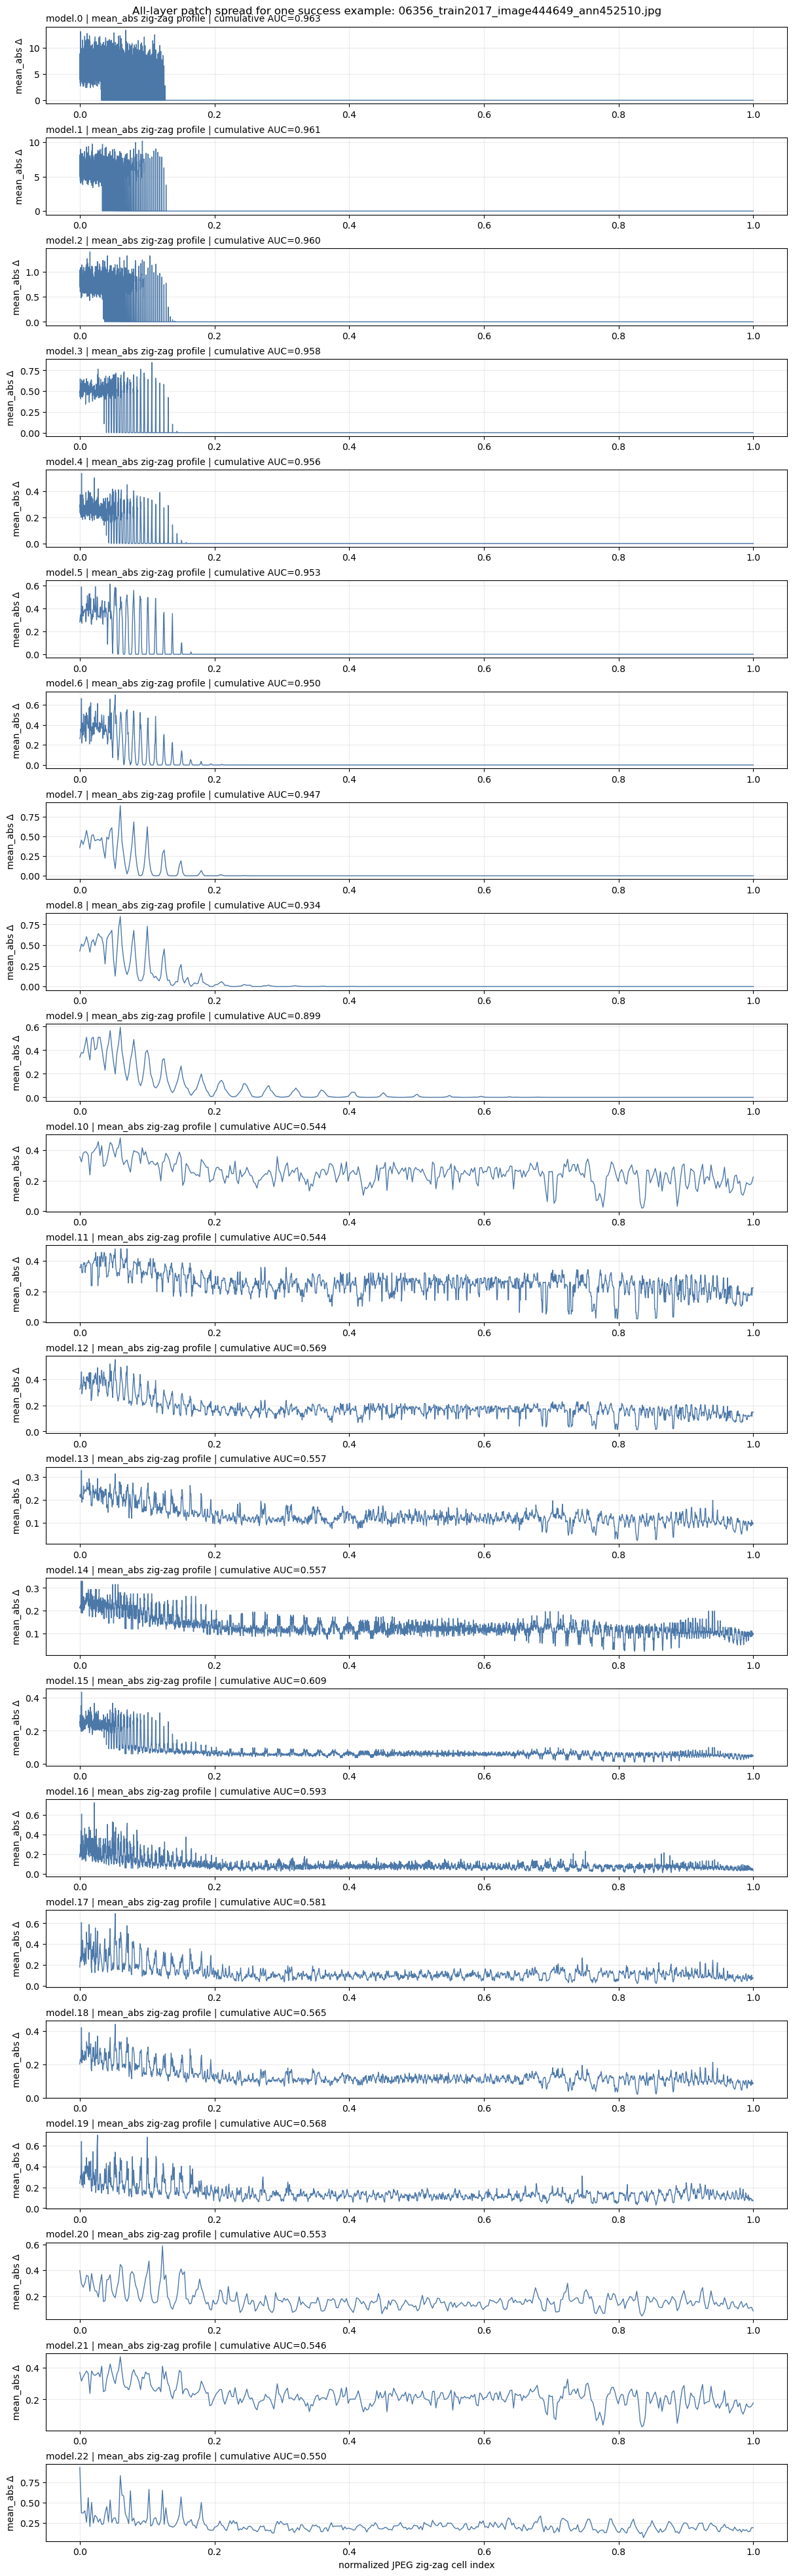

,layer,auc
0,model.0,0.962806
1,model.1,0.961303
2,model.2,0.960356
3,model.3,0.957976
4,model.4,0.956241
5,model.5,0.952570
6,model.6,0.950496
7,model.7,0.946584
8,model.8,0.934317
9,model.9,0.899311


In [3]:
cache = exp.get_cache()
one_example = cache.successes[0] if cache.successes else cache.examples[0]
layer_names = exp.all_display_layer_names()
_yolo, model = exp.load_model()
ctx = exp._context_for_example(one_example, image_variant="clean")
clean_pack = exp._preprocess(ctx["clean_lb"])
patched_pack = exp._preprocess(ctx["patched_lb"])
deltas = compute_layer_deltas(model, clean_pack["im"], patched_pack["im"], layer_names)

all_layer_profiles = []
for layer_name in layer_names:
    if layer_name not in deltas:
        continue
    profile = delta_zigzag_profile(deltas[layer_name].delta, mode="mean_abs")
    all_layer_profiles.append({
        "layer": layer_name,
        "x": np.linspace(0.0, 1.0, len(profile)),
        "profile": profile,
        "auc": normalized_cumulative_auc(profile),
    })

fig, axes = plt.subplots(len(all_layer_profiles), 1, figsize=(12, max(8, 1.7 * len(all_layer_profiles))), sharex=False, constrained_layout=True)
if len(all_layer_profiles) == 1:
    axes = [axes]
for ax, row in zip(axes, all_layer_profiles):
    ax.plot(row["x"], row["profile"], color="#4C78A8", linewidth=1.0)
    ax.set_title(f"{row['layer']} | mean_abs zig-zag profile | cumulative AUC={row['auc']:.3f}", loc="left", fontsize=10)
    ax.set_ylabel("mean_abs Δ")
    ax.grid(alpha=0.25)
axes[-1].set_xlabel("normalized JPEG zig-zag cell index")
fig.suptitle(f"All-layer patch spread for one success example: {Path(one_example.path).name}", y=1.002)
plt.show()

display(pd.DataFrame([{k: v for k, v in row.items() if k not in {"x", "profile"}} for row in all_layer_profiles]))


### Patch spread на 22 слое: success vs fail

Теперь берём n success и n fail, но уже не считаем IG и не гоняем модель. Используем `delta_chw` из `layer_maps_cache_path`, строим два набора профилей: `mean_abs` и `signed_mean`. На первом графике показываем только средние, на втором — средние с `± std`.


saved zigzag cache: new_experiments/outputs/patch_success_analysis/cache/patch_spread_zigzag_585c727f1b01c8c3.pkl
zigzag examples=5292 | success=2646 | fail=2646


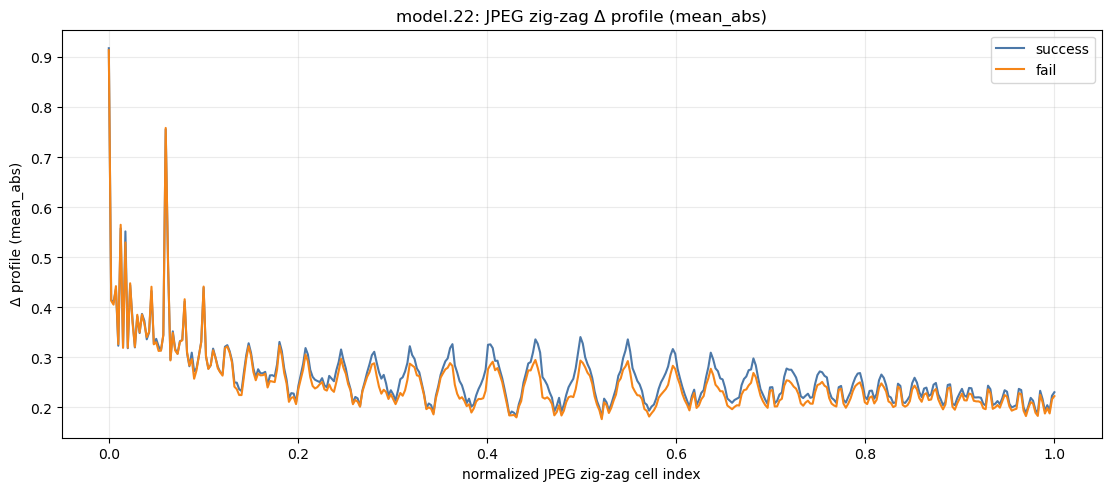

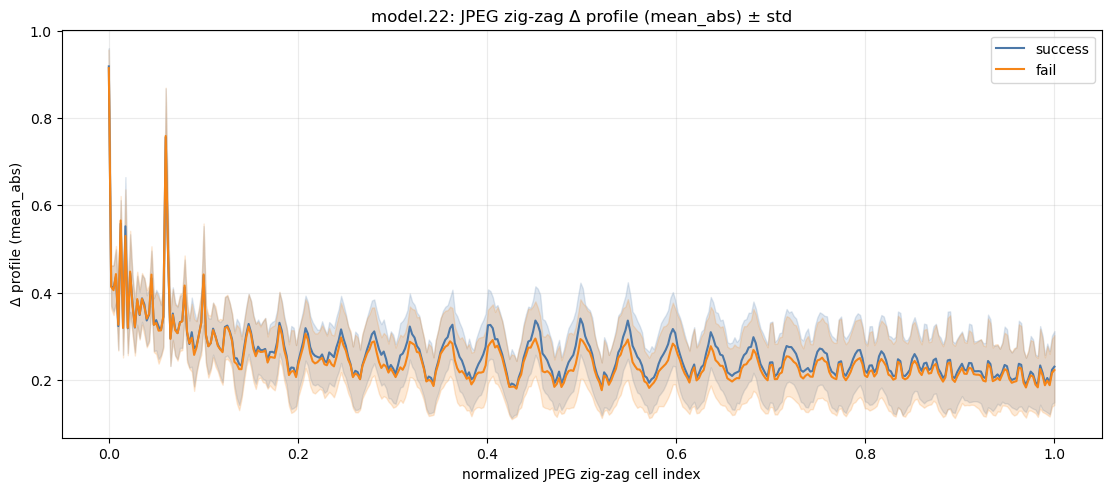

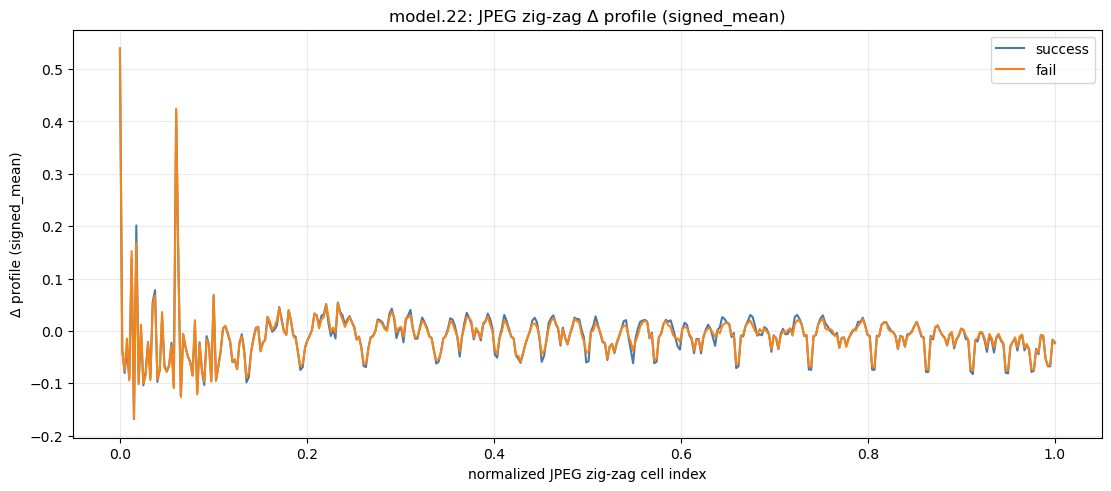

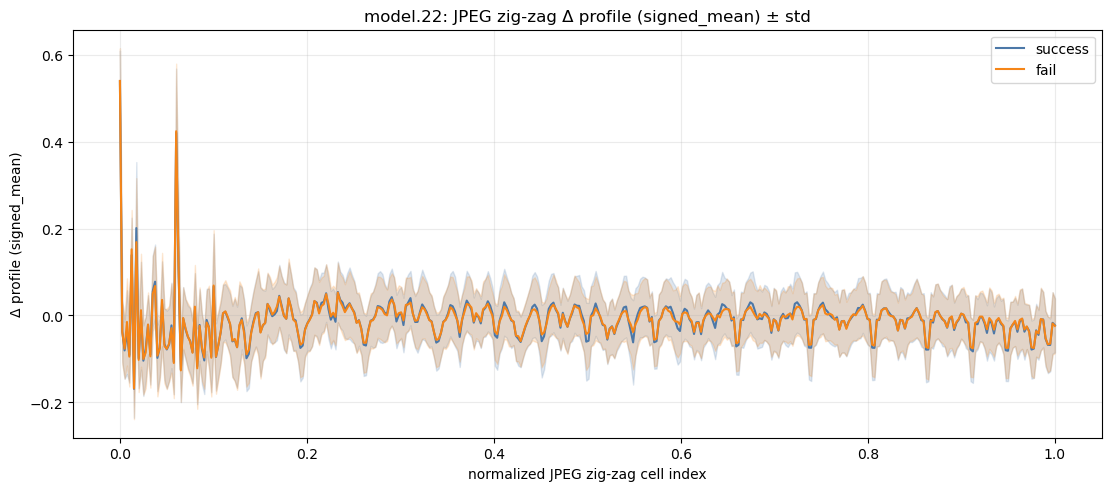

In [4]:
selected_zigzag_rows = select_balanced_rows(rows_df_full, per_class=zigzag_examples_per_class)

cache_payload = {
    "version": 1,
    "sf_cache_path": sf.get("cache_path"),
    "layer": zigzag_layer_name,
    "examples_per_class": zigzag_examples_per_class,
    "paths": selected_zigzag_rows["path"].tolist(),
    "modes": zigzag_modes,
}
cache_key = hashlib.sha256(json.dumps(cache_payload, sort_keys=True, ensure_ascii=True).encode("utf-8")).hexdigest()[:16]
zigzag_cache_path = exp.derived_cache_dir / f"patch_spread_zigzag_{cache_key}.pkl"

if zigzag_cache_path.exists():
    with zigzag_cache_path.open("rb") as f:
        zigzag_records = pickle.load(f)
    print(f"loaded zigzag cache: {zigzag_cache_path}")
else:
    zigzag_records = []
    for _, row in selected_zigzag_rows.iterrows():
        layer_map_path = resolve_existing_path(row["layer_maps_cache_path"])
        with np.load(layer_map_path, allow_pickle=False) as data:
            delta_chw = data["delta_chw"].astype("float32", copy=False)
        item = {
            "path": row["path"],
            "success": bool(row["success"]),
            "drop": float(row["drop"]),
            "layer_maps_cache_path": str(layer_map_path),
        }
        for mode in zigzag_modes:
            profile = delta_zigzag_profile(delta_chw, mode=mode)
            item[f"profile_{mode}"] = profile
            item[f"zigzag_cumulative_auc_{mode}"] = normalized_cumulative_auc(profile)
        zigzag_records.append(item)
    with zigzag_cache_path.open("wb") as f:
        pickle.dump(zigzag_records, f)
    print(f"saved zigzag cache: {zigzag_cache_path}")

print(f"zigzag examples={len(zigzag_records)} | success={sum(r['success'] for r in zigzag_records)} | fail={sum(not r['success'] for r in zigzag_records)}")
for mode in zigzag_modes:
    stats = _profile_group_stats(zigzag_records, mode)
    _plot_group_lines(stats, f"{zigzag_layer_name}: JPEG zig-zag Δ profile ({mode})", f"Δ profile ({mode})", with_std=False)
    _plot_group_lines(stats, f"{zigzag_layer_name}: JPEG zig-zag Δ profile ({mode}) ± std", f"Δ profile ({mode})", with_std=True)


### Кумулятивное расползание и AUC

Кумулятивная версия показывает, насколько быстро mass дельты набирается вдоль JPEG zig-zag порядка. Для `signed_mean` тоже берём `abs(profile)`, потому что тут нас интересует расползание magnitude, а не знак. AUC нормирован: `x` в `[0,1]`, cumulative mass заканчивается в `1`.


zigzag_cumulative_auc_mean_abs                  \
                                  mean       std count   
success                                                  
False                         0.545603  0.024972  2646   
True                          0.540766  0.022081  2646   

        zigzag_cumulative_auc_signed_mean                  
                                     mean       std count  
success                                                    
False                            0.561859  0.036172  2646  
True                             0.554134  0.032656  2646

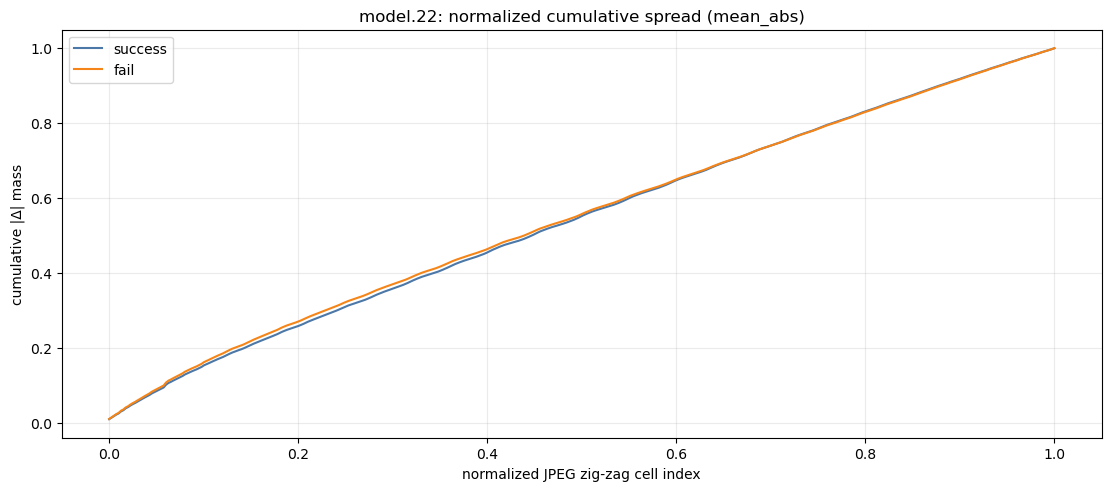

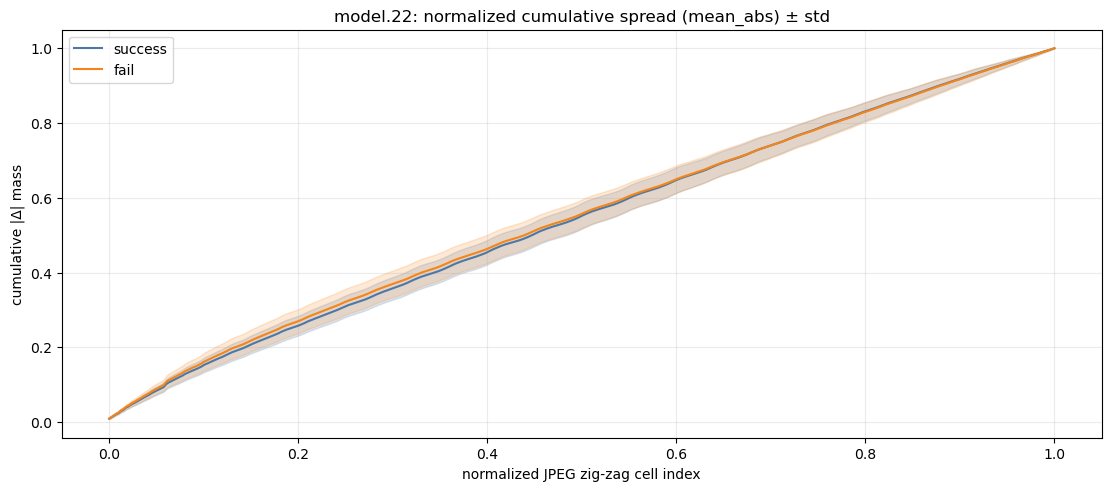

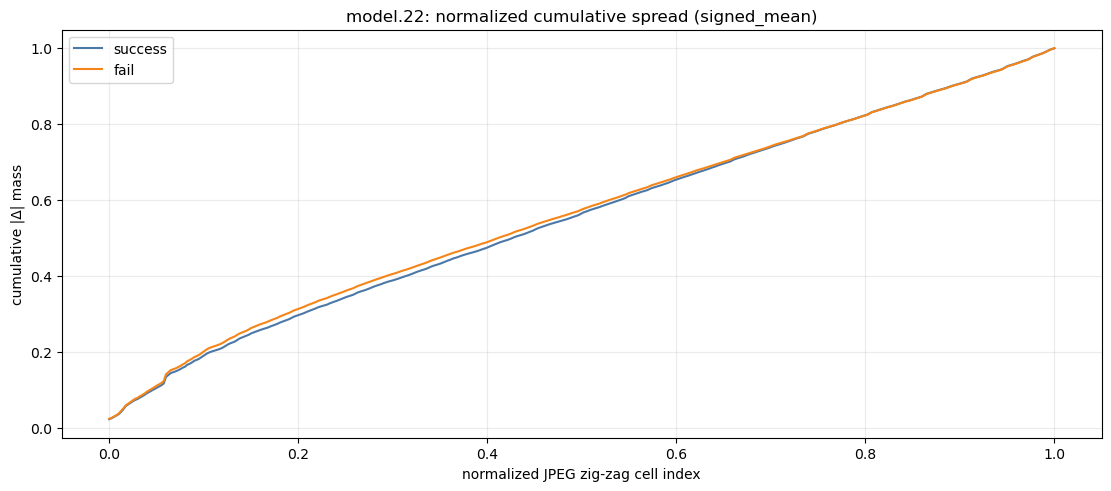

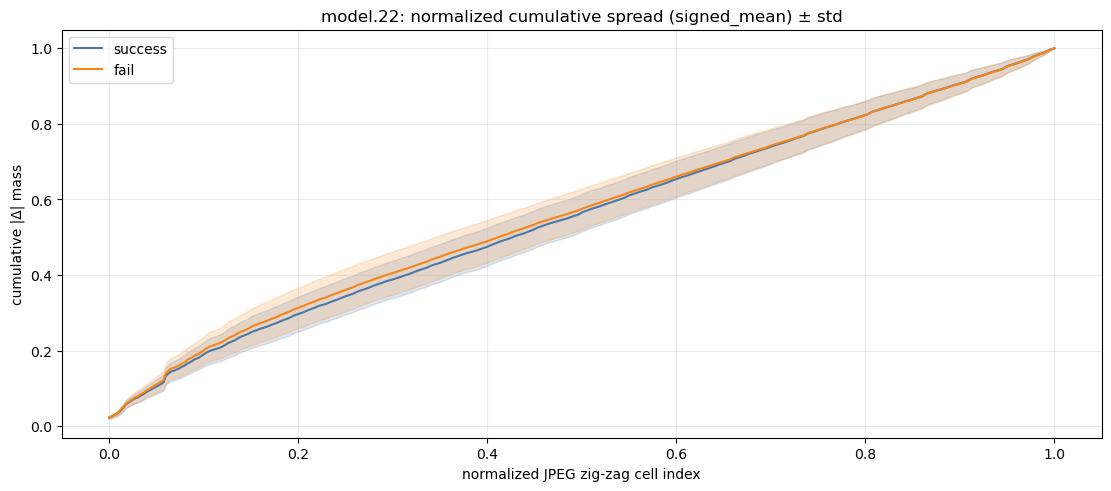

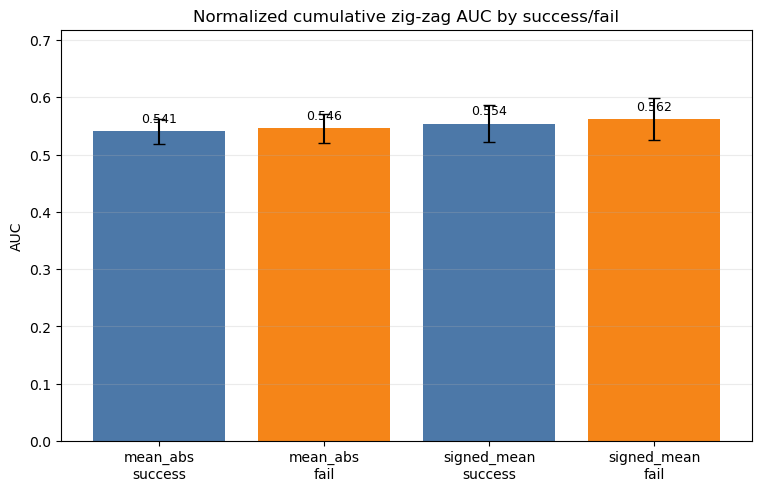

In [5]:
zigzag_metric_rows = []
for item in zigzag_records:
    out = {"path": item["path"], "success": bool(item["success"]), "drop": float(item["drop"])}
    for mode in zigzag_modes:
        out[f"zigzag_cumulative_auc_{mode}"] = float(item[f"zigzag_cumulative_auc_{mode}"])
    zigzag_metric_rows.append(out)
zigzag_metrics_df = pd.DataFrame(zigzag_metric_rows)
display(zigzag_metrics_df.groupby("success")[[f"zigzag_cumulative_auc_{mode}" for mode in zigzag_modes]].agg(["mean", "std", "count"]))

for mode in zigzag_modes:
    stats = _cumulative_group_stats(zigzag_records, mode)
    _plot_group_lines(stats, f"{zigzag_layer_name}: normalized cumulative spread ({mode})", "cumulative |Δ| mass", with_std=False)
    _plot_group_lines(stats, f"{zigzag_layer_name}: normalized cumulative spread ({mode}) ± std", "cumulative |Δ| mass", with_std=True)

bar_rows = []
for mode in zigzag_modes:
    metric = f"zigzag_cumulative_auc_{mode}"
    for success_value, label in [(True, "success"), (False, "fail")]:
        values = zigzag_metrics_df.loc[zigzag_metrics_df["success"] == success_value, metric].astype("float64")
        bar_rows.append({"mode": mode, "label": label, "mean": values.mean(), "std": values.std()})
bar_df = pd.DataFrame(bar_rows)
fig, ax = plt.subplots(figsize=(7.5, 4.8), constrained_layout=True)
labels = [f"{row.mode}\n{row.label}" for row in bar_df.itertuples()]
x = np.arange(len(bar_df))
colors = ["#4C78A8" if label.endswith("success") else "#F58518" for label in labels]
bars = ax.bar(x, bar_df["mean"], yerr=bar_df["std"], capsize=4, color=colors)
for bar, value in zip(bars, bar_df["mean"]):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.01, f"{value:.3f}", ha="center", va="bottom", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0.0, min(1.0, float((bar_df["mean"] + bar_df["std"].fillna(0)).max()) + 0.12))
ax.set_title("Normalized cumulative zig-zag AUC by success/fail")
ax.set_ylabel("AUC")
ax.grid(axis="y", alpha=0.25)
plt.show()


### Разделение success/fail по zig-zag AUC

Проверяем, насколько normalized cumulative AUC сам по себе разделяет success/fail: строим distribution + ROC и выводим те же `roc_auc`, `best_accuracy`, `best_threshold`, `best_direction`.


,metric,roc_auc,best_accuracy,best_threshold,best_direction
0,zigzag_cumulative_auc_mean_abs,0.443774,0.554800,0.552708,-1
1,zigzag_cumulative_auc_signed_mean,0.439999,0.545729,0.557713,-1


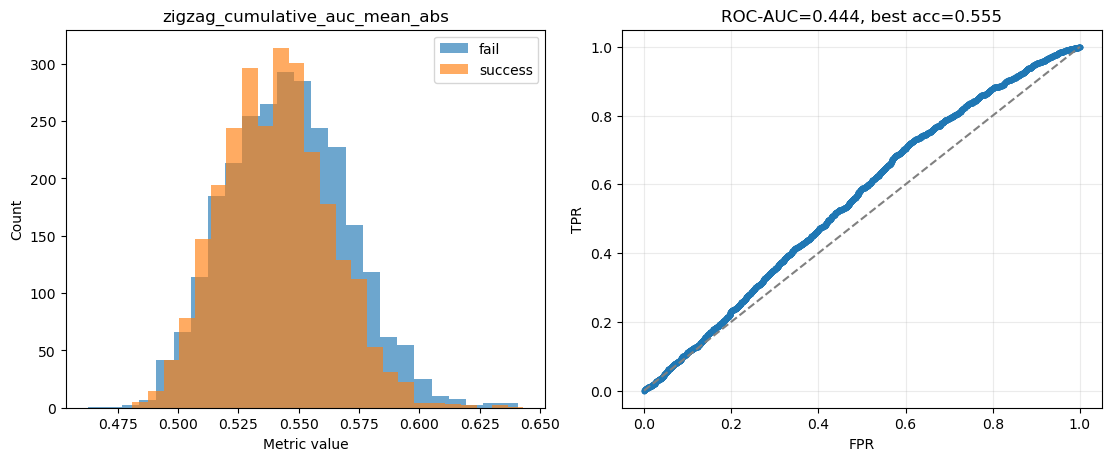

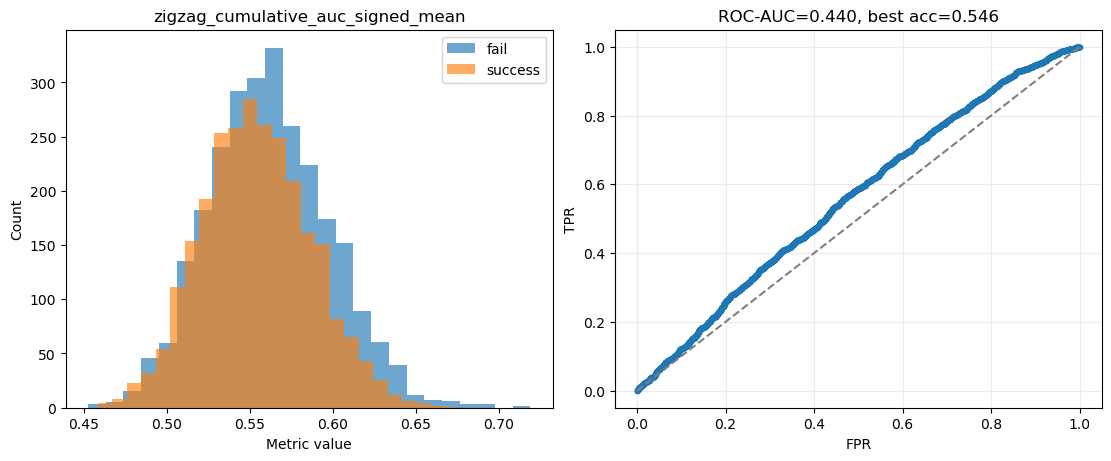

In [6]:
zigzag_metric_names = [f"zigzag_cumulative_auc_{mode}" for mode in zigzag_modes]
zigzag_quality = pd.DataFrame(metric_quality_rows(
    zigzag_metrics_df["success"].astype(bool).tolist(),
    {name: zigzag_metrics_df[name].astype("float64").to_numpy() for name in zigzag_metric_names},
)).sort_values(["best_accuracy", "roc_auc"], ascending=False)
display(zigzag_quality)

for _, row in zigzag_quality.iterrows():
    metric = row["metric"]
    fig = plot_metric_distribution_and_roc(
        zigzag_metrics_df["success"].astype(bool).to_numpy(),
        zigzag_metrics_df[metric].astype("float64").to_numpy(),
        metric_name=metric,
        auc=float(row["roc_auc"]),
        best_accuracy=float(row["best_accuracy"]),
        direction=int(row["best_direction"]),
    )
    plt.show()


## Channel-filtered patch spread experiments

Перенесенные spread-эксперименты: выбираем top 1%, top 10% и все каналы по unsigned channel importance на `model.22`, дальше анализируем spread уже на уровне нейронов/пространства.

In [7]:
import importlib
import patch_success_analysis.channel_metrics as channel_metrics

channel_metrics = importlib.reload(channel_metrics)

channel_layer_name = zigzag_layer_name
channel_fractions = (1, 10, 100)
force_channel_summary_recompute = False

selected_examples = channel_metrics.select_balanced_examples(
    exp,
    per_class=analysis_examples_per_class,
)
channel_summary = channel_metrics.compute_or_load_channel_summary(
    exp,
    selected_examples,
    layer_name=channel_layer_name,
    force=force_channel_summary_recompute,
)
print(
    f"selected={len(selected_examples)} "
    f"({sum(e.success for e in selected_examples)} success / {sum(not e.success for e in selected_examples)} fail)"
)
print(f"channel summary cache: {channel_summary['cache_path']}")
print(f"channel rows={channel_summary.get('n_examples')}, skipped={channel_summary.get('n_skipped', len(channel_summary.get('skipped', [])))}")
print(f"loaded_from_cache={channel_summary['loaded_from_cache']}")


selected=5300 (2650 success / 2650 fail)
channel summary cache: new_experiments/outputs/patch_success_analysis/cache/channel_summary_dd02dc3c8554b088.pkl
channel rows=5296, skipped=4
loaded_from_cache=True


### Channel-filtered spatial maps

Визуально проверяем top-channel subsets до ranked/spread графиков: для нескольких отдельных изображений показываем clean image, карты mean abs delta и карты mean abs importance для top 1%, top 10% и всех каналов. Ниже строим такие же карты, усредненные отдельно по success/fail.

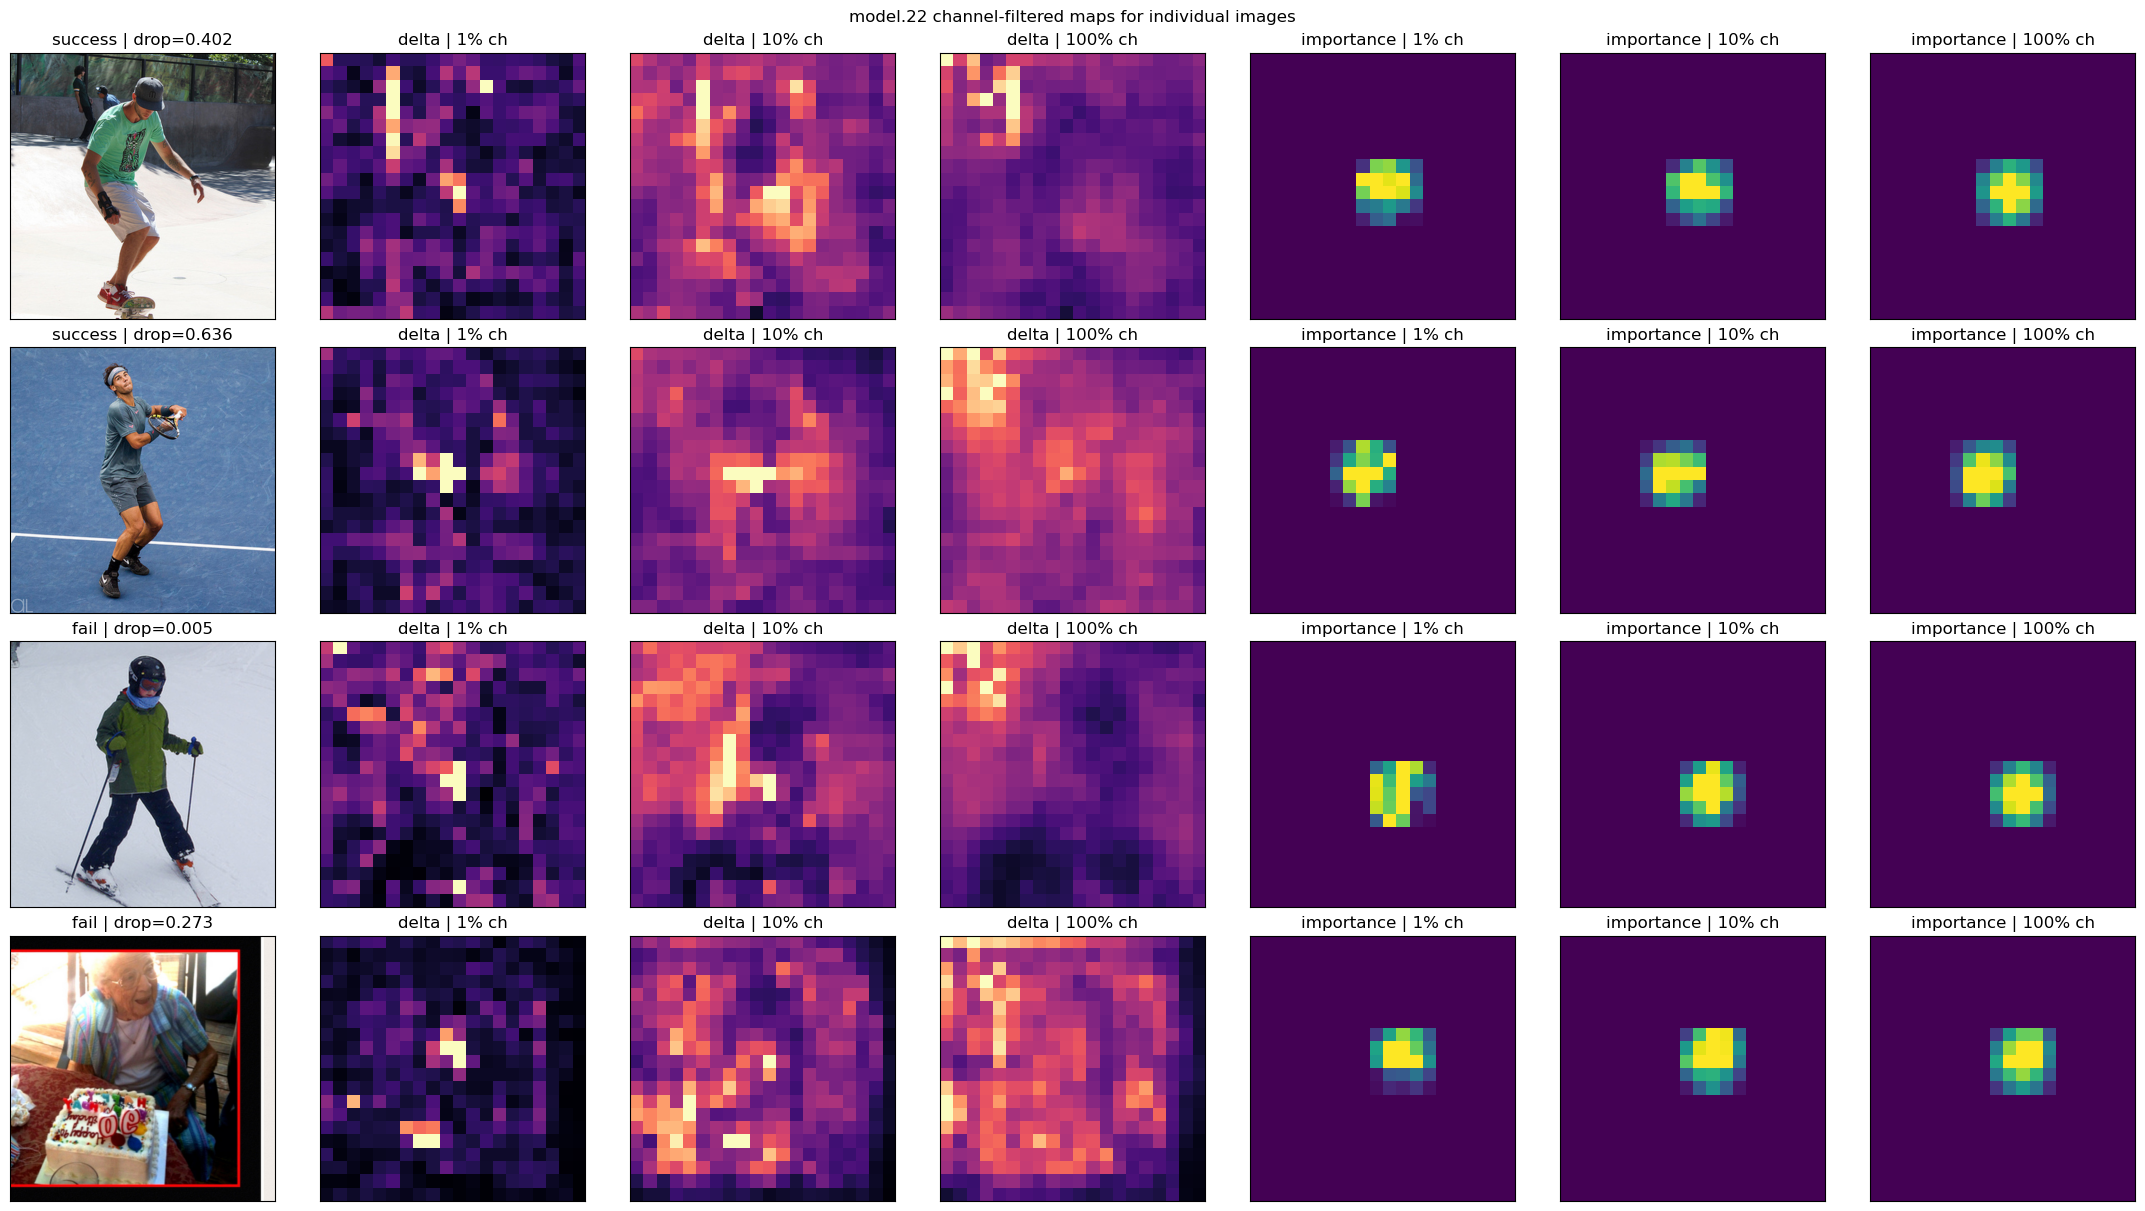

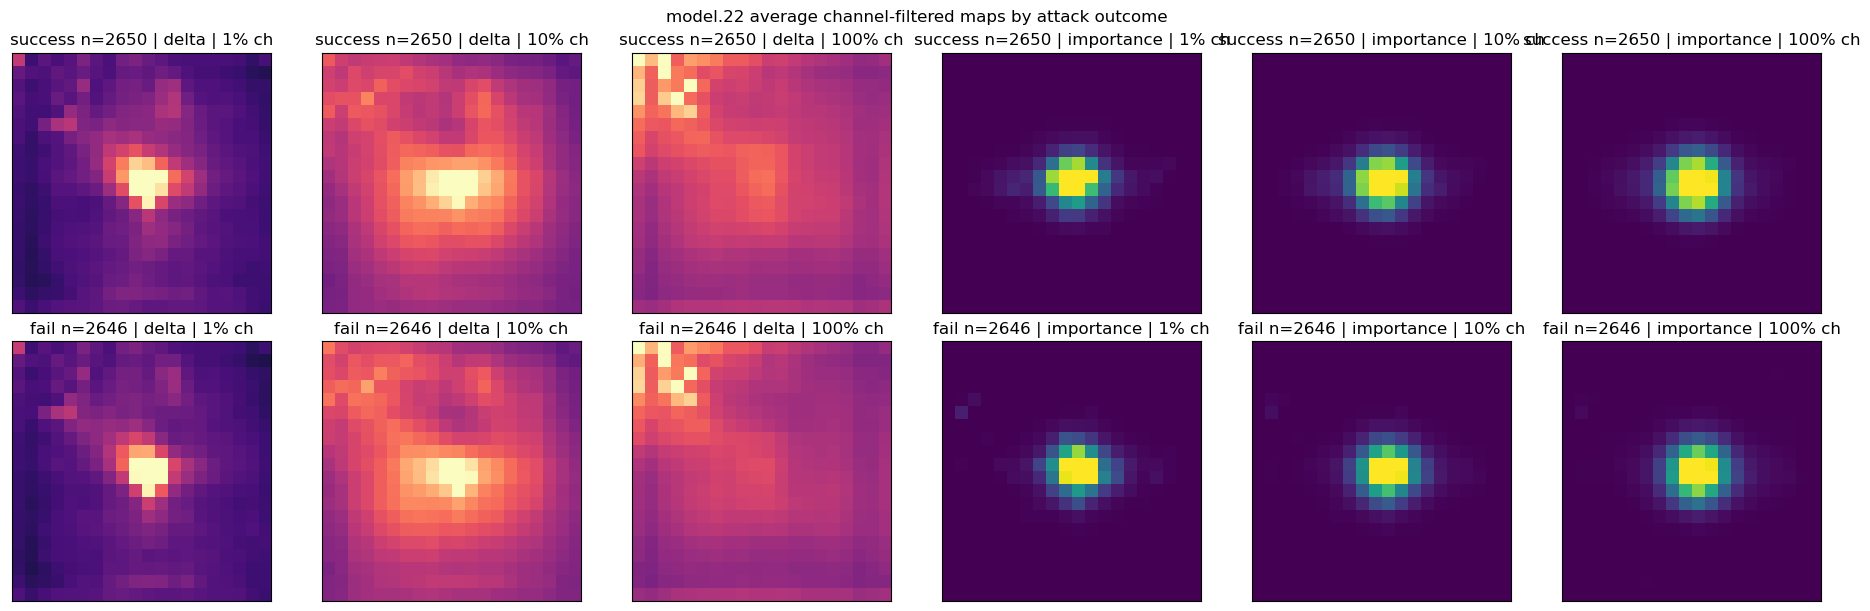

channel-filtered maps cache: new_experiments/outputs/patch_success_analysis/cache/channel_filtered_spatial_maps_v1_ind2_4950f423cc20508b.pkl
loaded_from_cache=True
averaged rows: 2650 success / 2646 fail, skipped=4
new_experiments/outputs/patch_success_analysis/figures/channel_filtered_spatial_maps_individual_model_22.png
new_experiments/outputs/patch_success_analysis/figures/channel_filtered_spatial_maps_average_model_22.png


In [8]:
channel_metrics = importlib.reload(channel_metrics)

force_channel_filtered_maps_recompute = False
channel_filtered_individual_per_class = 2

channel_filtered_maps_result = channel_metrics.compute_or_load_channel_filtered_spatial_map_summary(
    exp,
    channel_summary,
    selected_examples,
    fractions=channel_fractions,
    individual_per_class=channel_filtered_individual_per_class,
    force=force_channel_filtered_maps_recompute,
)
channel_filtered_maps = channel_filtered_maps_result["maps"]

fig = channel_metrics.plot_channel_filtered_individual_spatial_maps(channel_filtered_maps)
channel_filtered_individual_fig_path = exp.figures_dir / "channel_filtered_spatial_maps_individual_model_22.png"
fig.savefig(channel_filtered_individual_fig_path, dpi=160, bbox_inches="tight")
plt.show()

fig = channel_metrics.plot_channel_filtered_average_spatial_maps(channel_filtered_maps)
channel_filtered_average_fig_path = exp.figures_dir / "channel_filtered_spatial_maps_average_model_22.png"
fig.savefig(channel_filtered_average_fig_path, dpi=160, bbox_inches="tight")
plt.show()

print(f"channel-filtered maps cache: {channel_filtered_maps_result['cache_path']}")
print(f"loaded_from_cache={channel_filtered_maps_result['loaded_from_cache']}")
print(
    f"averaged rows: {channel_filtered_maps.get('n_success')} success / "
    f"{channel_filtered_maps.get('n_fail')} fail, skipped={channel_filtered_maps.get('n_skipped')}"
)
print(channel_filtered_individual_fig_path)
print(channel_filtered_average_fig_path)


### Ranked neuron deltas

Первые три строки показывают signed delta, следующие три строки показывают `mean(abs(delta))` по примерам для каждого нейрона. Нейроны сортируются по убыванию unsigned importance внутри выбранных каналов.

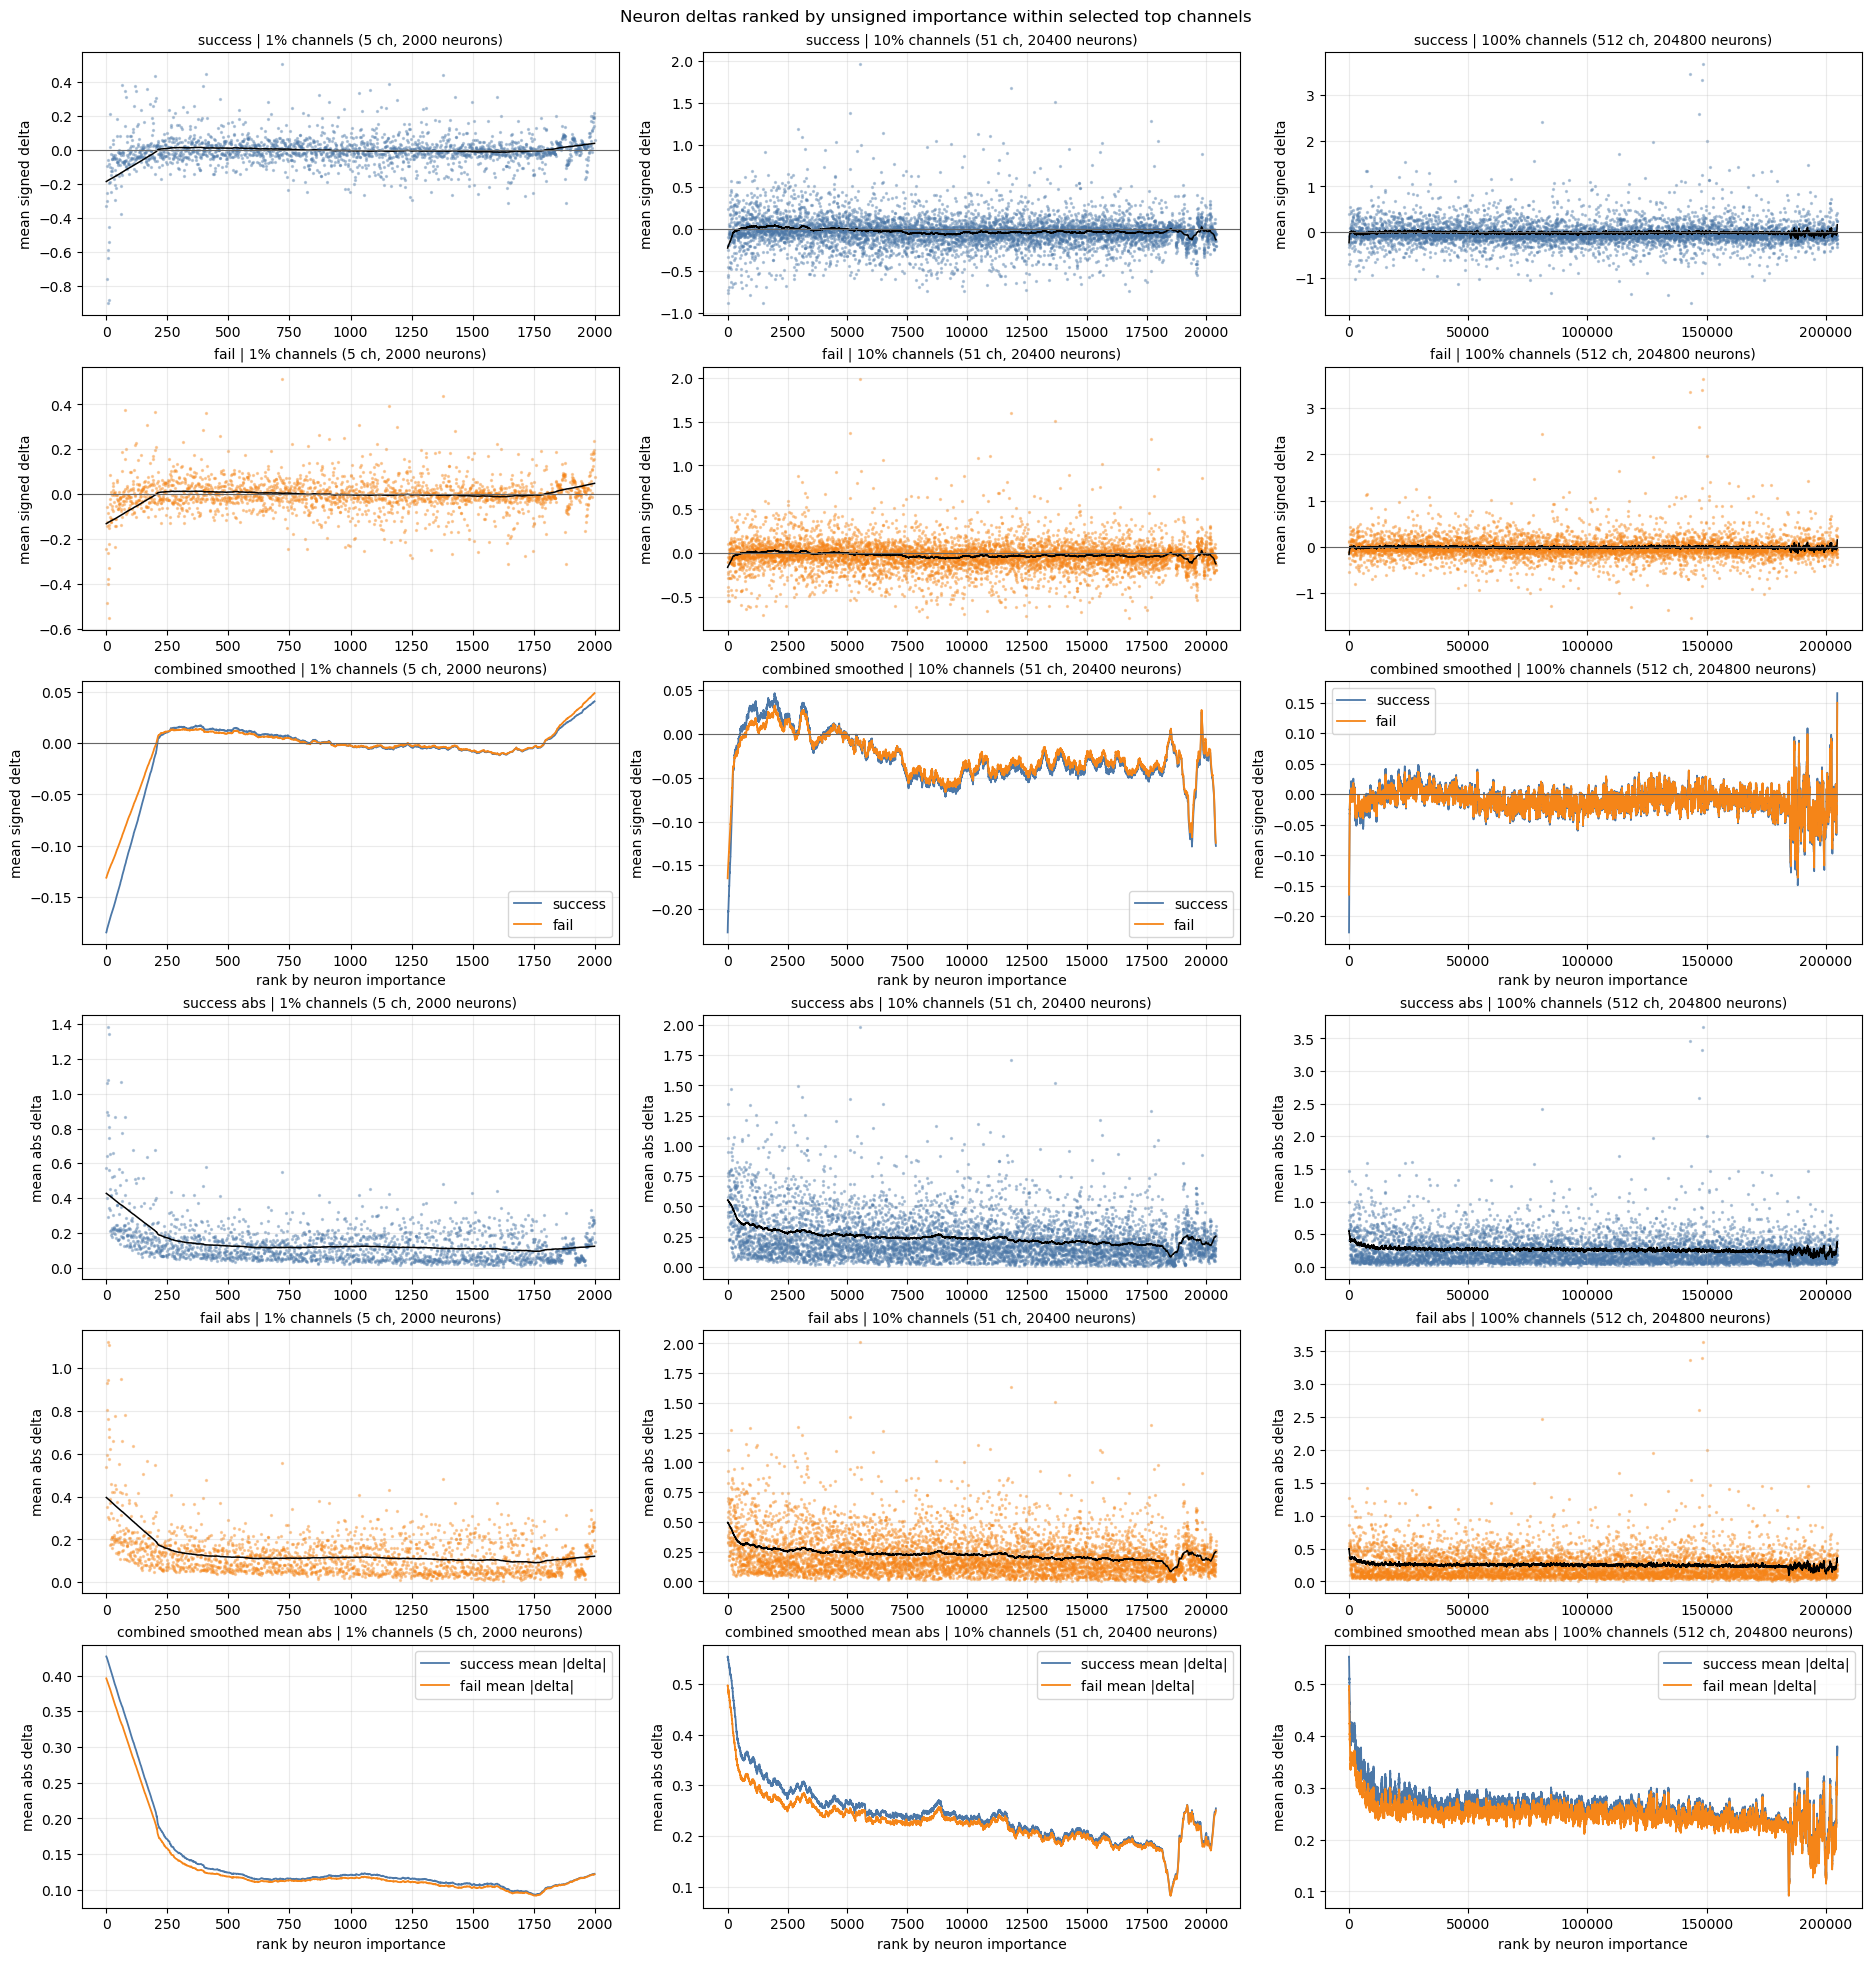

ranked neuron cache: new_experiments/outputs/patch_success_analysis/cache/ranked_neuron_delta_abs_v2_7e9449646189f893.pkl
loaded_from_cache=True
new_experiments/outputs/patch_success_analysis/figures/ranked_neuron_delta_top_channels_model_22.png


In [9]:
channel_metrics = importlib.reload(channel_metrics)

force_ranked_neuron_delta_recompute = False

ranked_result = channel_metrics.compute_or_load_ranked_neuron_delta_by_channel_fraction(
    exp,
    channel_summary,
    selected_examples,
    fractions=channel_fractions,
    force=force_ranked_neuron_delta_recompute,
)
fig = channel_metrics.plot_ranked_neuron_delta_by_channel_fraction(
    ranked_result["ranked"],
    smooth_window=401,
)
ranked_fig_path = exp.figures_dir / "ranked_neuron_delta_top_channels_model_22.png"
fig.savefig(ranked_fig_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"ranked neuron cache: {ranked_result['cache_path']}")
print(f"loaded_from_cache={ranked_result['loaded_from_cache']}")
print(ranked_fig_path)


### Spiral spread

Квадратная спираль из центра картинки и из центра объекта. Сверху delta со std-заливками, ниже те же delta-кривые без дисперсий плюс importance для того же обхода.

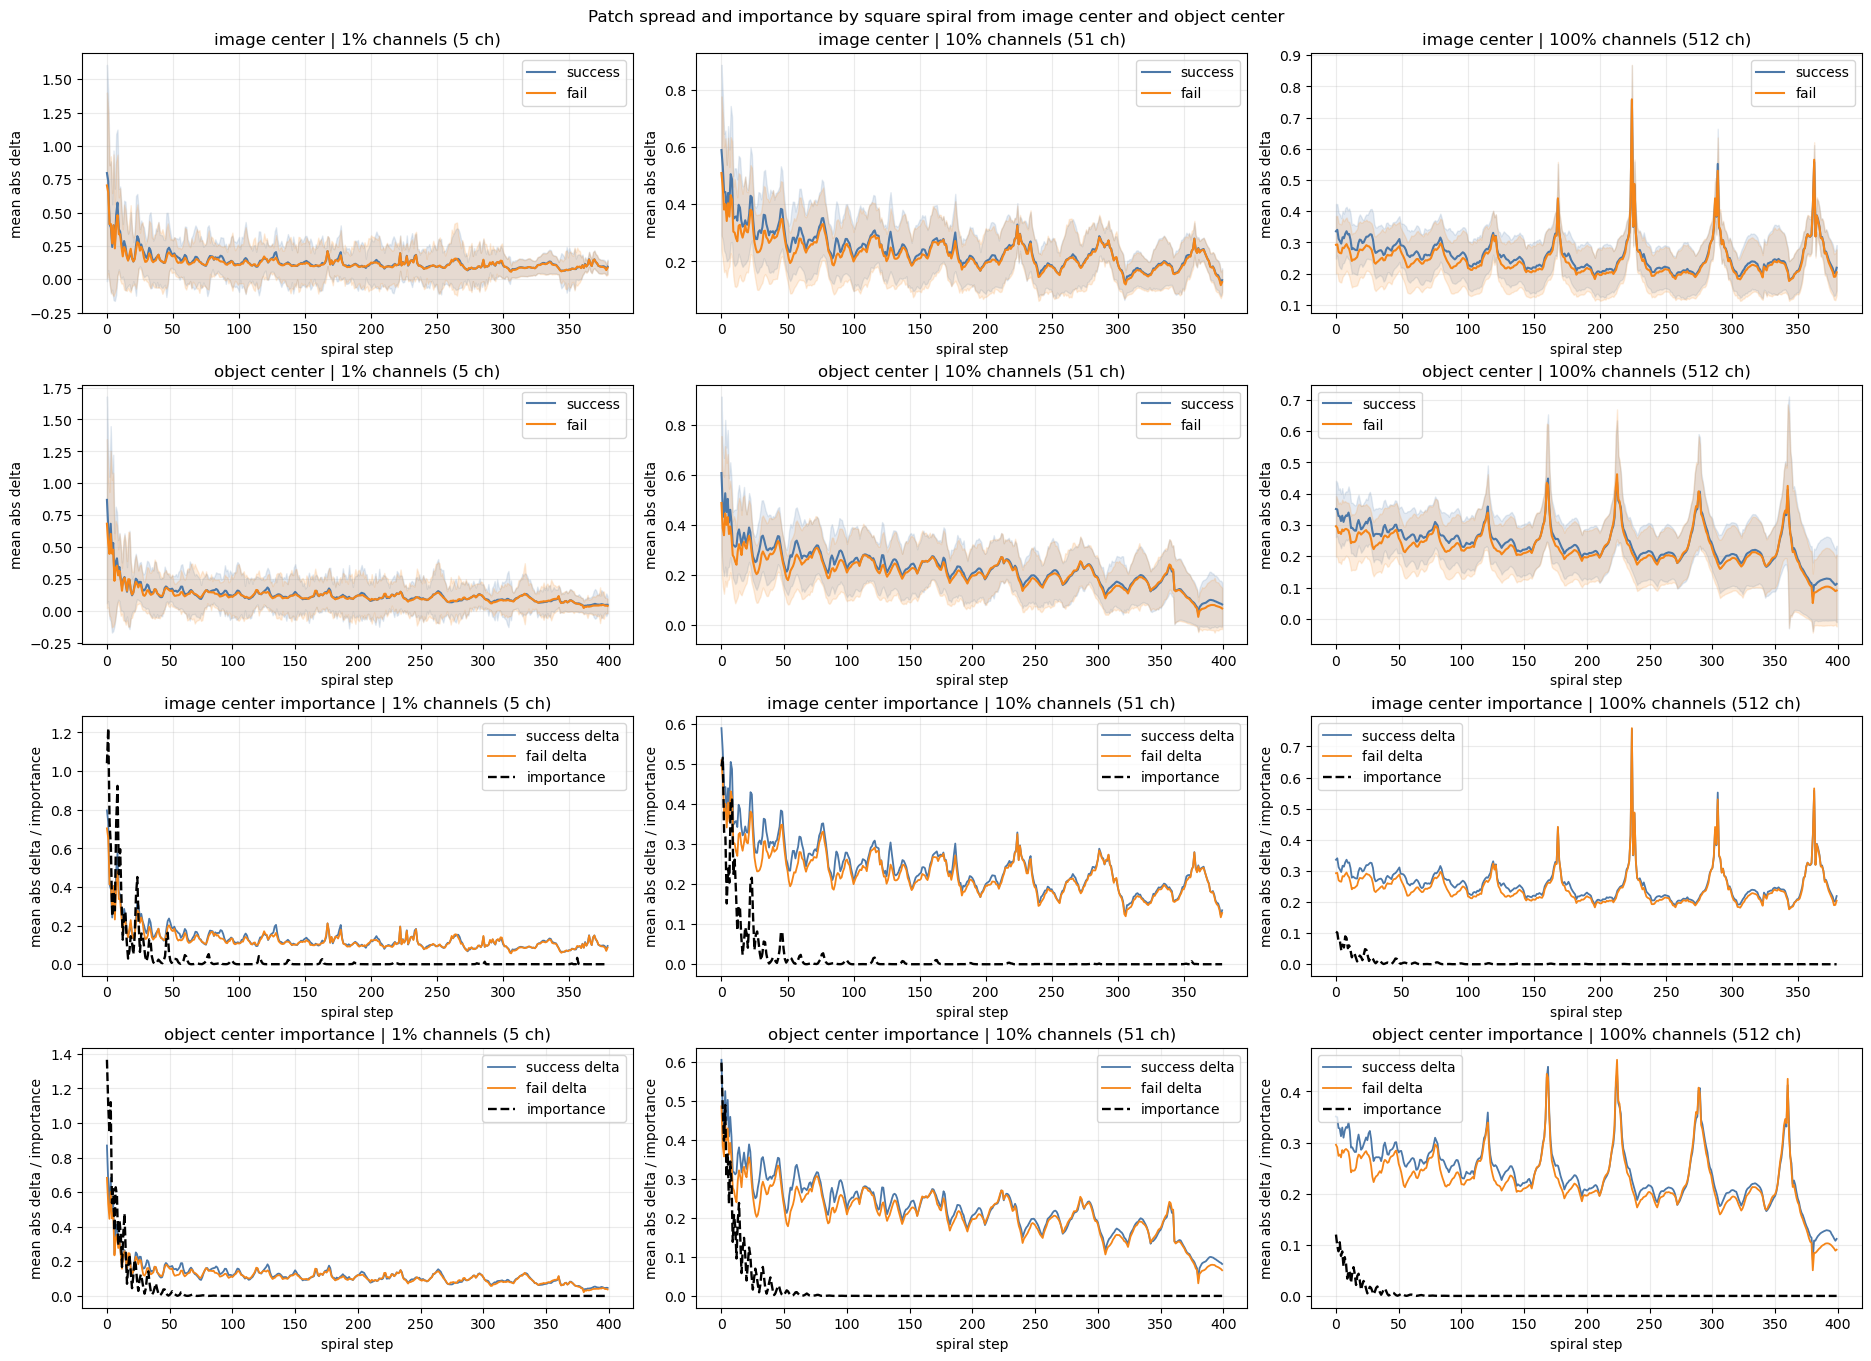

spiral cache: new_experiments/outputs/patch_success_analysis/cache/spiral_delta_profiles_with_importance_v2_57bac6d51c3eb135.pkl
loaded_from_cache=True
new_experiments/outputs/patch_success_analysis/figures/spiral_delta_profiles_top_channels_model_22.png


In [10]:
channel_metrics = importlib.reload(channel_metrics)

force_spiral_delta_recompute = False

spiral_result = channel_metrics.compute_or_load_spiral_delta_profiles_by_channel_fraction(
    exp,
    channel_summary,
    selected_examples,
    fractions=channel_fractions,
    force=force_spiral_delta_recompute,
)
fig = channel_metrics.plot_spiral_delta_profiles(spiral_result["profiles"])
spiral_fig_path = exp.figures_dir / "spiral_delta_profiles_top_channels_model_22.png"
fig.savefig(spiral_fig_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"spiral cache: {spiral_result['cache_path']}")
print(f"loaded_from_cache={spiral_result['loaded_from_cache']}")
print(spiral_fig_path)


### Centered square rings

Идем квадратными кольцами из центра картинки. Для `20x20` feature map первое кольцо содержит 4 центральные клетки, каждое следующее кольцо содержит только новую квадратную рамку вокруг предыдущих. Сверху delta со std-заливками, ниже те же delta-кривые без дисперсий плюс importance.

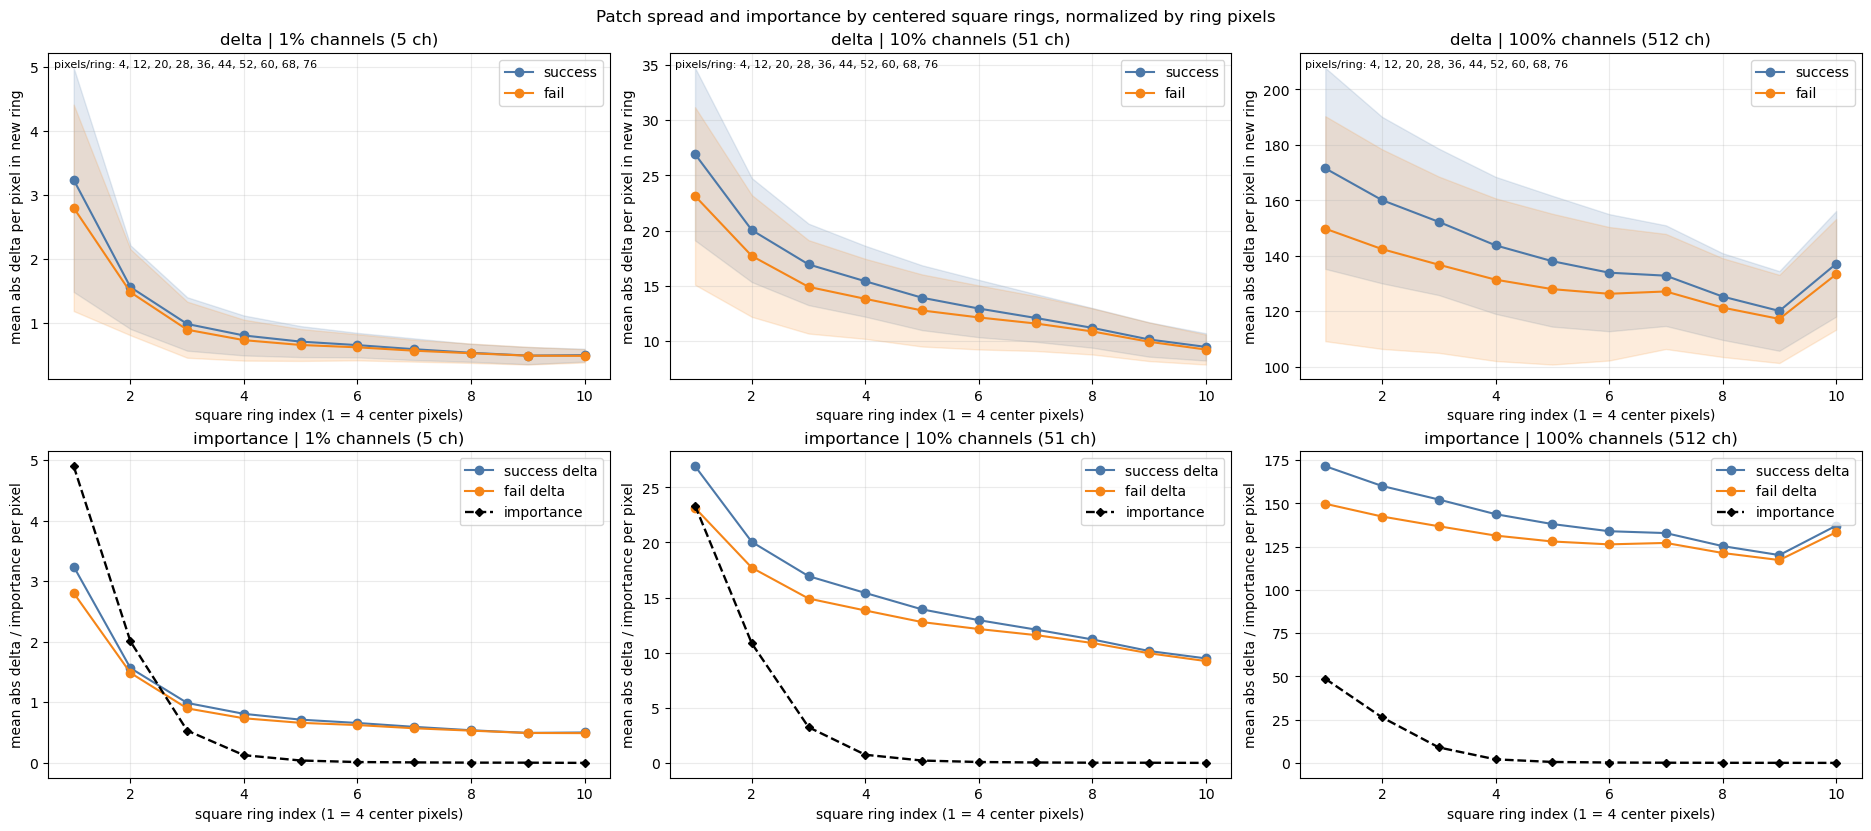

square ring cache: new_experiments/outputs/patch_success_analysis/cache/square_ring_delta_profiles_pixel_norm_v4_617f6d51beef42b2.pkl
loaded_from_cache=True
new_experiments/outputs/patch_success_analysis/figures/square_ring_delta_profiles_top_channels_model_22.png


In [11]:
channel_metrics = importlib.reload(channel_metrics)

force_square_ring_delta_recompute = False

square_ring_result = channel_metrics.compute_or_load_square_ring_delta_profiles_by_channel_fraction(
    exp,
    channel_summary,
    selected_examples,
    fractions=channel_fractions,
    force=force_square_ring_delta_recompute,
)
fig = channel_metrics.plot_square_ring_delta_profiles(square_ring_result["profiles"])
square_ring_fig_path = exp.figures_dir / "square_ring_delta_profiles_top_channels_model_22.png"
fig.savefig(square_ring_fig_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"square ring cache: {square_ring_result['cache_path']}")
print(f"loaded_from_cache={square_ring_result['loaded_from_cache']}")
print(square_ring_fig_path)


### Cached failure diagnosis

Диагностика из финальной ячейки `GeneralExperiments`, но через актуальный кэшированный путь: используем уже сохраненные `delta_chw` и `segmentig_chw` из `layer_maps`, без пересчета Full IG/NAA/SegmentIG.

,drop,delta_l2_rms,topk_energy_frac,layer_maps_loaded_from_cache,segmentig_align_cosine,segmentig_align_top_jaccard,segmentig_importance_energy_in_delta_top,segmentig_delta_energy_in_importance_top
success,,,,,,,,
False,0.117636,0.463925,0.108328,1.0,0.054099,0.037652,0.126836,0.056256
True,0.711765,0.482682,0.104805,1.0,0.063801,0.044264,0.149385,0.062336


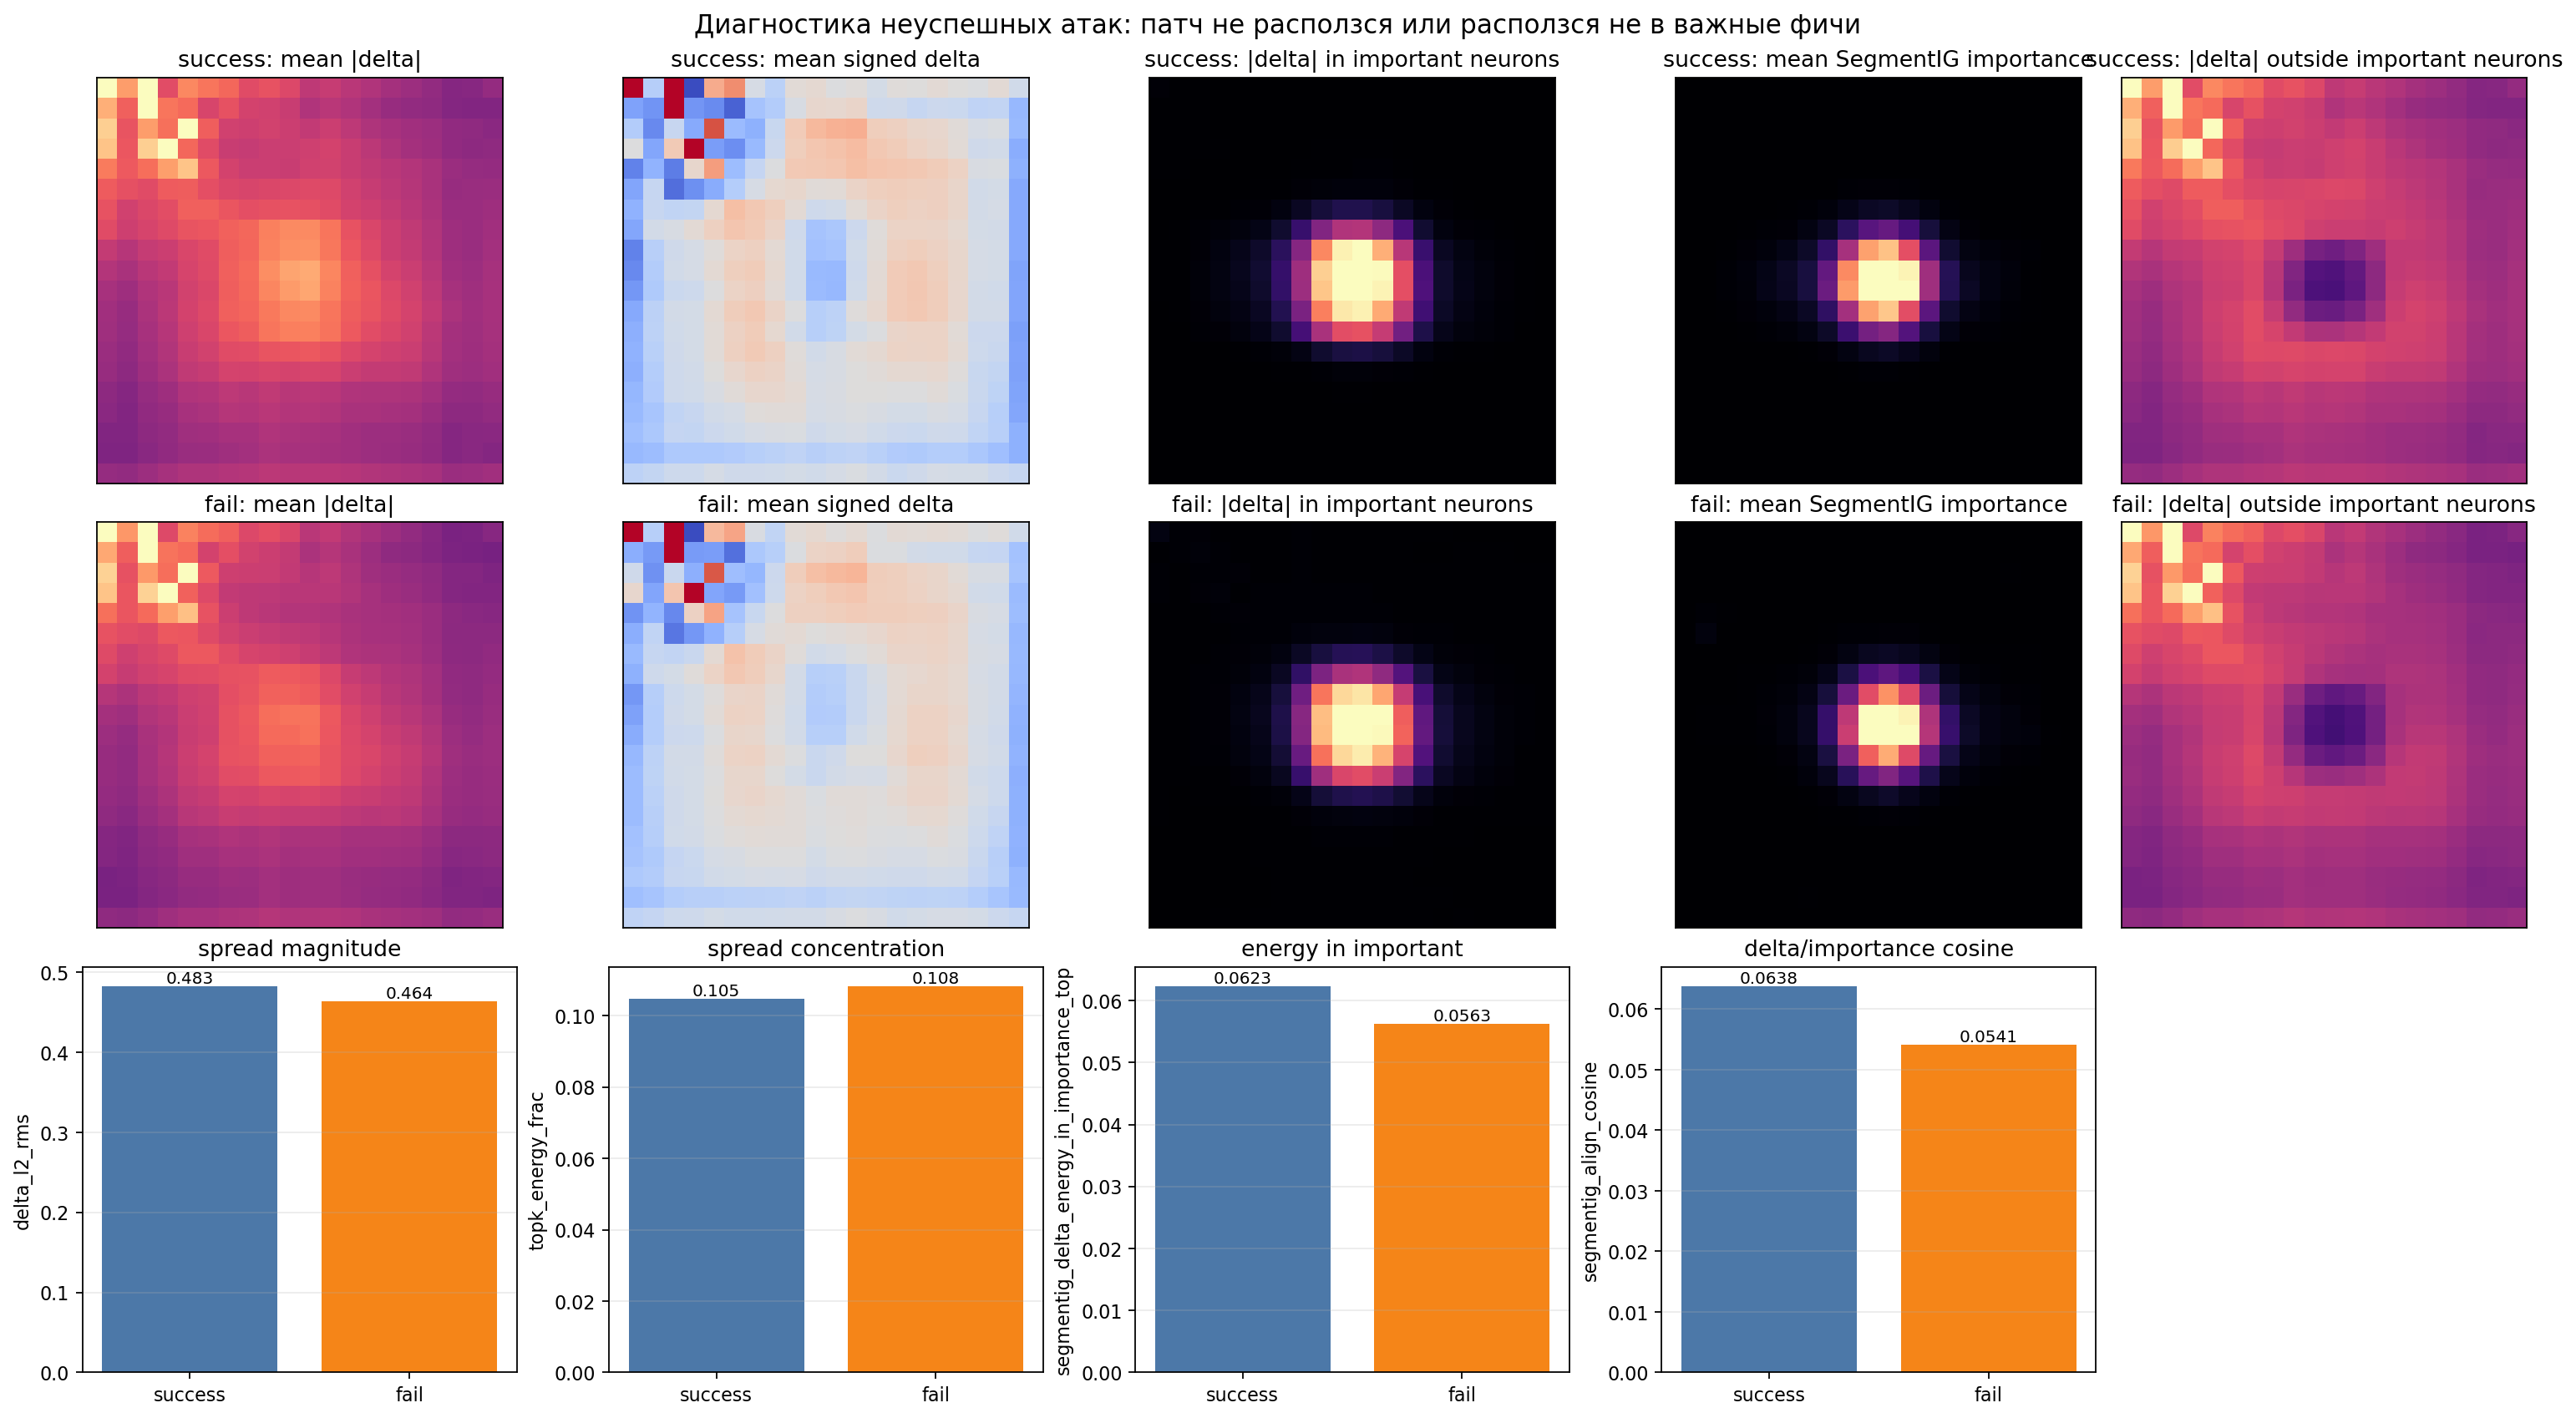

failure diagnosis cache: new_experiments/outputs/patch_success_analysis/cache/cached_failure_diagnosis_v1_bda78f81ebe6e987.pkl
loaded_from_cache=True
rows=5296 (2650 success / 2646 fail), skipped=4
new_experiments/outputs/patch_success_analysis/figures/failure_diagnosis_cached_segmentig_layer_maps.png


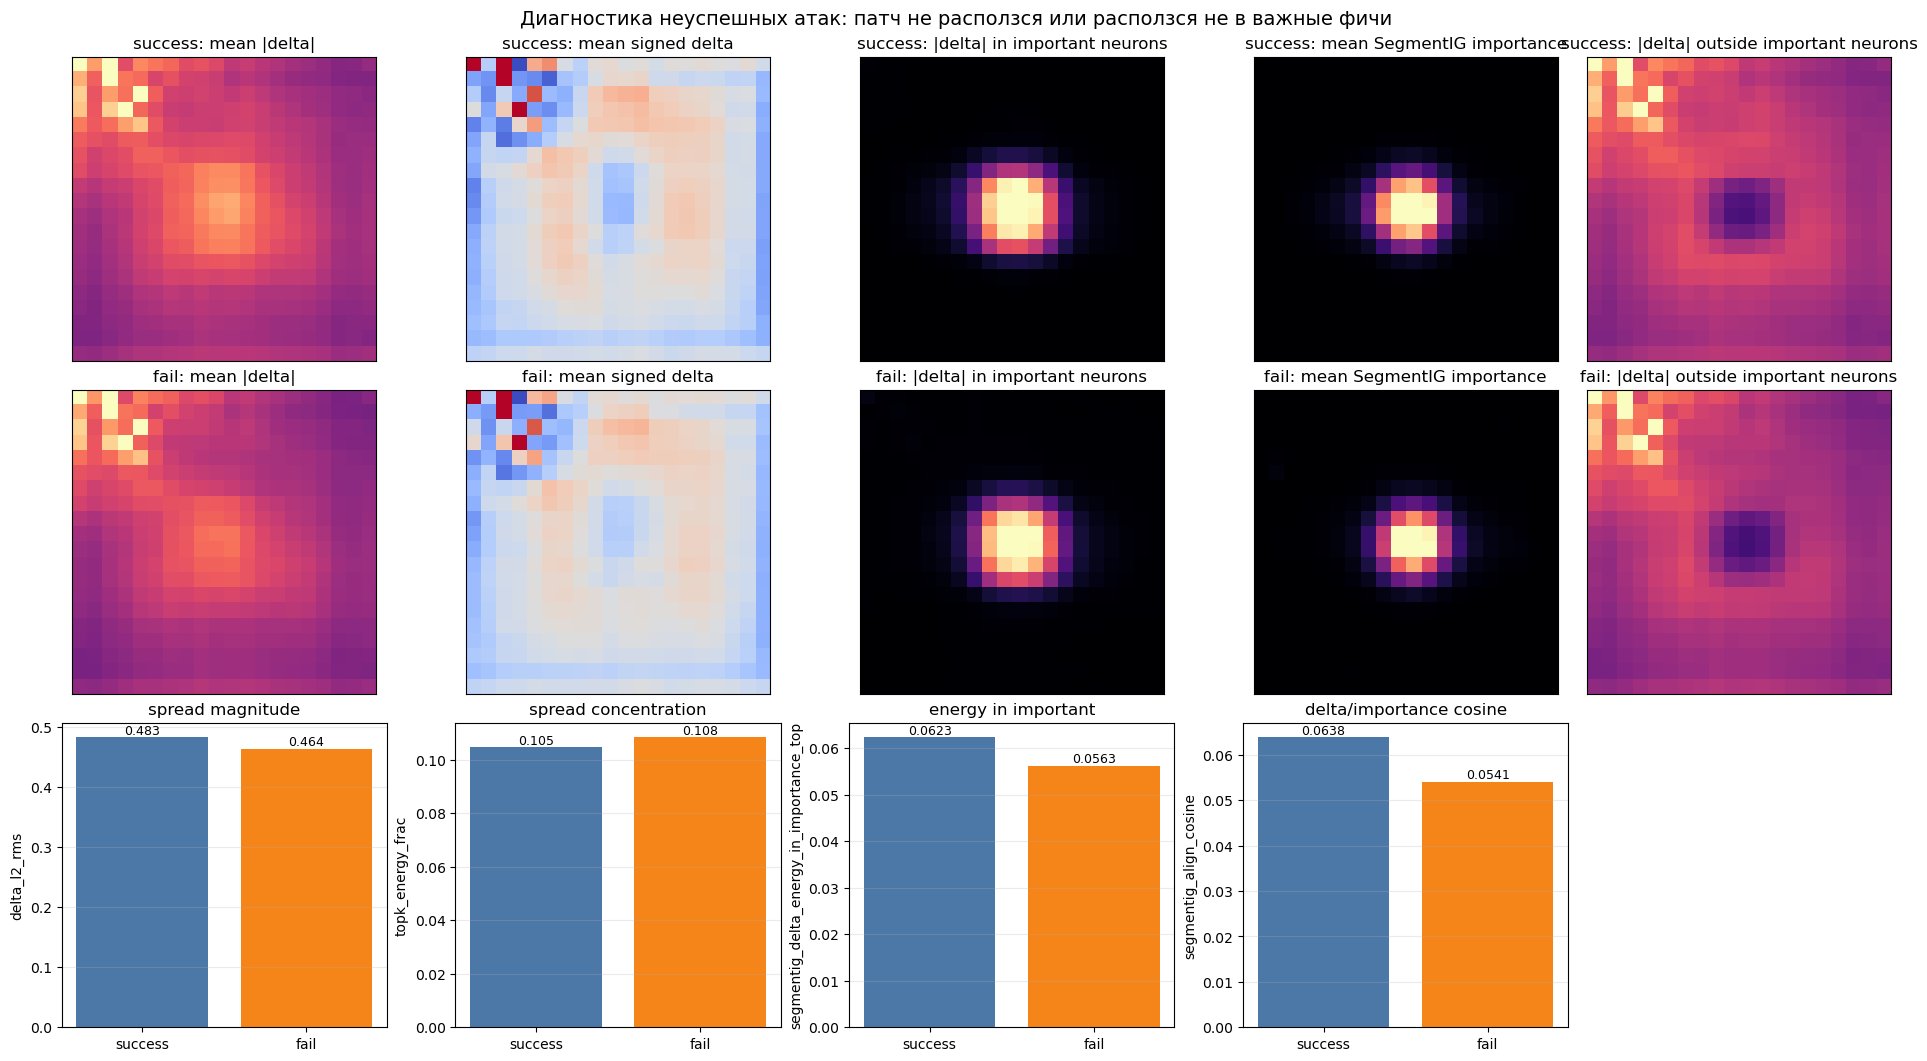

In [12]:
from IPython.display import Image, display

channel_metrics = importlib.reload(channel_metrics)

force_failure_diagnosis_recompute = False
failure_top_percent = 5.0

failure_result = channel_metrics.compute_or_load_cached_failure_diagnosis(
    exp,
    selected_examples,
    layer_name=channel_layer_name,
    top_percent=failure_top_percent,
    force=force_failure_diagnosis_recompute,
)
failure_diagnosis = failure_result["diagnosis"]
failure_rows_df = pd.DataFrame(failure_diagnosis["rows"])
display(failure_rows_df.groupby("success").mean(numeric_only=True))
display(Image(filename=failure_diagnosis["figure_path"]))
print(f"failure diagnosis cache: {failure_result['cache_path']}")
print(f"loaded_from_cache={failure_result['loaded_from_cache']}")
print(
    f"rows={len(failure_rows_df)} "
    f"({failure_diagnosis.get('n_success')} success / {failure_diagnosis.get('n_fail')} fail), "
    f"skipped={failure_diagnosis.get('n_skipped')}"
)
print(failure_diagnosis["figure_path"])


## Patch-excluded spread metrics

Считаем основные метрики распространения патча по уже сохранённым `delta_chw`, но исключаем саму область патча из знаменателя и из object-bbox метрик. Новая ключевая метрика: `object_bbox_delta_frac_no_patch` — доля энергии `Δ` внутри clean bbox объекта до атаки, без области патча.

Метрики считаются для всех каналов, top 10% и top 1% каналов по суммарной `|SegmentIG|` внутри каждого изображения.

patch-excluded spread cache: new_experiments/outputs/patch_success_analysis/cache/patch_excluded_spread_metrics_d7655781c59b0ab9.pkl
loaded_from_cache=False
rows=16938, skipped=4


,path,success,drop,reason
0,../datasets/COCO_people/03520_train2017_image1...,False,-0.147283,missing layer_maps cache
1,../datasets/COCO_people/03370_train2017_image5...,False,-0.751137,missing layer_maps cache
2,../datasets/COCO_people/01029_train2017_image3...,False,-0.195723,missing layer_maps cache
3,../datasets/COCO_people/04404_train2017_image7...,False,0.000000,missing layer_maps cache


,path,success,drop,conf_clean,conf_patch,subset,percent,n_channels,delta_l2_rms_no_patch,delta_abs_mean_no_patch,...,patch_roi_energy_frac_total,object_bbox_delta_frac_no_patch,object_bbox_delta_sum_no_patch,object_bbox_delta_mean_no_patch,object_bbox_delta_max_no_patch,object_bbox_delta_signed_mean_no_patch,object_bbox_feature_pixels_no_patch,delta_total_abs_no_patch,delta_total_signed_no_patch,importance_total_abs_no_patch
0,../datasets/COCO_people/06356_train2017_image4...,True,0.402123,0.933572,0.531450,top_1pct_channels,1.0,5,0.523351,0.398842,...,0.054742,0.664235,99.346865,0.522878,1.835062,0.071246,190.0,546.658875,133.524963,17.808790
1,../datasets/COCO_people/06356_train2017_image4...,True,0.402123,0.933572,0.531450,top_10pct_channels,10.0,51,0.441522,0.409609,...,0.083061,0.581785,89.363964,0.470337,1.111487,0.054826,190.0,4814.908203,310.213165,96.751534
2,../datasets/COCO_people/06356_train2017_image4...,True,0.402123,0.933572,0.531450,all_channels,100.0,512,0.385786,0.359146,...,0.111960,0.559840,75.399139,0.396838,1.355305,0.016901,190.0,40971.582031,32.911987,266.837219
3,../datasets/COCO_people/00972_train2017_image3...,True,0.636096,0.876672,0.240576,top_1pct_channels,1.0,5,0.528199,0.427279,...,0.054736,0.492013,78.835053,0.518652,1.584112,-0.000808,152.0,568.824585,107.819031,97.906448
4,../datasets/COCO_people/00972_train2017_image3...,True,0.636096,0.876672,0.240576,top_10pct_channels,10.0,51,0.437250,0.412373,...,0.090787,0.449795,69.556307,0.457607,1.134047,0.013030,152.0,5019.381348,-212.390213,278.247131


delta_l2_rms_no_patch                      \
                                           count      mean       std   
subset             success                                             
all_channels       False                    2646  0.436009  0.076072   
                   True                     3000  0.458005  0.065393   
top_10pct_channels False                    2646  0.450655  0.087422   
                   True                     3000  0.473901  0.075951   
top_1pct_channels  False                    2646  0.418876  0.135641   
                   True                     3000  0.436198  0.132190   

                                     delta_abs_mean_no_patch            \
                              median                   count      mean   
subset             success                                               
all_channels       False    0.428557                    2646  0.410032   
                   True     0.456615                    3000  0.431935   
top_10pct_channels False    0.439169                    2646  0.410974   
                   True     0.470951                    3000  0.434746   
top_1pct_channels  False    0.405289                    2646  0.323919   
                   True     0.426683                    3000  0.341426   

                                               delta_max_no_patch            \
                                 std    median              count      mean   
subset             success                                                    
all_channels       False    0.075330  0.401178               2646  1.053401   
                   True     0.065283  0.430617               3000  1.077746   
top_10pct_channels False    0.082465  0.398864               2646  1.373719   
                   True     0.072970  0.430575               3000  1.422234   
top_1pct_channels  False    0.109844  0.316068               2646  1.857182   
                   True     0.109914  0.336965               3000  1.895966   

                            ... object_bbox_delta_frac_no_patch            \
                            ...                             std    median   
subset             success  ...                                             
all_channels       False    ...                        0.226387  0.584141   
                   True     ...                        0.158677  0.535572   
top_10pct_channels False    ...                        0.229271  0.607219   
                   True     ...                        0.159545  0.552926   
top_1pct_channels  False    ...                        0.234199  0.606539   
                   True     ...                        0.169284  0.557698   

                           object_bbox_delta_mean_no_patch            \
                                                     count      mean   
subset             success                                             
all_channels       False                              2646  0.413976   
                   True                               3000  0.477635   
top_10pct_channels False                              2646  0.430092   
                   True                               3000  0.496435   
top_1pct_channels  False                              2646  0.338561   
                   True                               3000  0.389781   

                                               patch_roi_energy_frac_total  \
                                 std    median                       count   
subset             success                                                   
all_channels       False    0.131271  0.423087                        2646   
                   True     0.077672  0.479115                        3000   
top_10pct_channels False    0.143264  0.435115                        2646   
                   True     0.092457  0.493472                        3000   
top_1pct_channels  False    0.154569  0.335365                        2646   
                   True     0.13

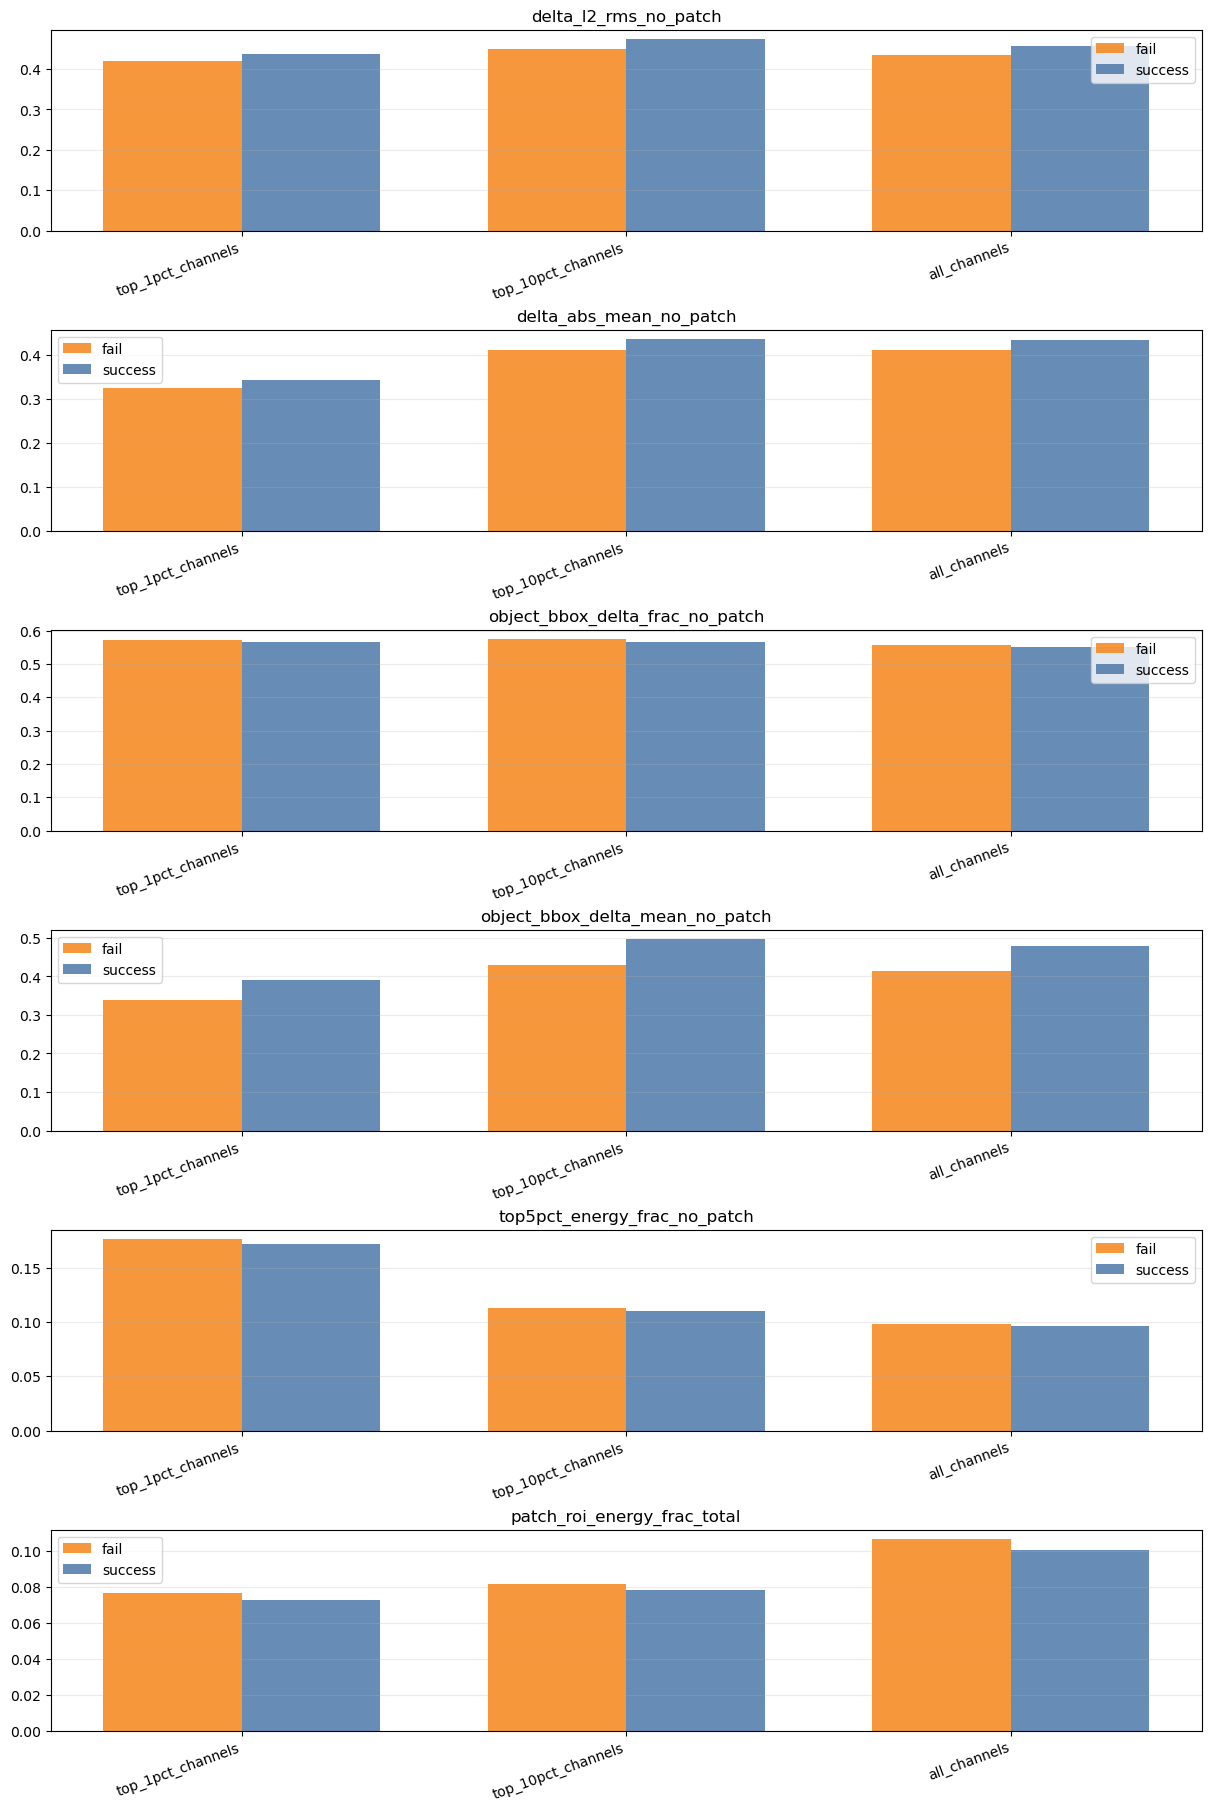

In [13]:
import importlib
from patch_success_analysis import spread_precision

spread_precision = importlib.reload(spread_precision)

force_patch_excluded_spread_recompute = False
patch_excluded_fractions = (1, 10, 100)

patch_excluded_result = spread_precision.compute_or_load_patch_excluded_spread_metrics(
    exp,
    cache.examples,
    layer_name=layer_name,
    fractions=patch_excluded_fractions,
    force=force_patch_excluded_spread_recompute,
)
patch_excluded_df = patch_excluded_result["rows_df"]

print(f"patch-excluded spread cache: {patch_excluded_result['cache_path']}")
print(f"loaded_from_cache={patch_excluded_result['loaded_from_cache']}")
print(f"rows={len(patch_excluded_df)}, skipped={len(patch_excluded_result.get('skipped', []))}")
if patch_excluded_result.get("skipped"):
    display(pd.DataFrame(patch_excluded_result["skipped"]).head(20))

display(patch_excluded_df.head())
display(
    patch_excluded_df.groupby(["subset", "success"])[[
        "delta_l2_rms_no_patch",
        "delta_abs_mean_no_patch",
        "delta_max_no_patch",
        "delta_gini_no_patch",
        "top5pct_energy_frac_no_patch",
        "object_bbox_delta_frac_no_patch",
        "object_bbox_delta_mean_no_patch",
        "patch_roi_energy_frac_total",
    ]].agg(["count", "mean", "std", "median"])
)
fig = spread_precision.plot_patch_excluded_spread_summary(patch_excluded_df)
plt.show()

### Patch-excluded metrics vs drop

,subset,metric,n,coverage,pearson,spearman,kendall,abs_pearson,abs_spearman,abs_kendall,...,target_std,linear_slope,linear_intercept,linear_r2,calibrated_mae,calibrated_rmse,calibrated_nrmse,mutual_info_norm,calibrated_error_score,main_score
30,all_channels,object_bbox_delta_mean_no_patch,5646,1.0,0.290273,0.245456,0.171399,0.290273,0.245456,0.171399,...,0.339241,0.888309,0.034942,0.084258,0.283657,0.324606,0.956944,1.000000,0.511001,0.366081
15,top_10pct_channels,object_bbox_delta_mean_no_patch,5646,1.0,0.266607,0.230639,0.160250,0.266607,0.230639,0.160250,...,0.339241,0.732284,0.091964,0.071079,0.287432,0.326934,0.963805,1.000000,0.509215,0.355223
0,top_1pct_channels,object_bbox_delta_mean_no_patch,5646,1.0,0.163955,0.159736,0.108476,0.163955,0.159736,0.108476,...,0.339241,0.372844,0.296350,0.026881,0.299534,0.334621,0.986468,0.773099,0.503406,0.269368
32,all_channels,delta_total_abs_no_patch,5646,1.0,0.151665,0.154616,0.105662,0.151665,0.154616,0.105662,...,0.339241,0.000007,0.099372,0.023002,0.298378,0.335287,0.988432,0.407450,0.502909,0.215849
18,top_10pct_channels,delta_total_abs_no_patch,5646,1.0,0.139632,0.147107,0.100128,0.139632,0.147107,0.100128,...,0.339241,0.000053,0.168350,0.019497,0.299616,0.335888,0.990203,0.356303,0.502461,0.202751
31,all_channels,object_bbox_delta_max_no_patch,5646,1.0,0.195591,0.144474,0.098113,0.195591,0.144474,0.098113,...,0.339241,0.248036,0.190126,0.038256,0.297403,0.332660,0.980686,0.533199,0.504876,0.240699
16,top_10pct_channels,object_bbox_delta_max_no_patch,5646,1.0,0.161804,0.141356,0.095973,0.161804,0.141356,0.095973,...,0.339241,0.117493,0.278633,0.026181,0.299991,0.334741,0.986823,0.616655,0.503316,0.240490
36,all_channels,patch_roi_energy_frac_total,5646,1.0,-0.145256,-0.129182,-0.087415,0.145256,0.129182,0.087415,...,0.339241,-3.063632,0.749456,0.021099,0.299098,0.335614,0.989394,0.263947,0.502666,0.185846
37,all_channels,delta_abs_mean_no_patch,5646,1.0,0.121491,0.126418,0.085825,0.121491,0.126418,0.085825,...,0.339241,0.580403,0.187989,0.014760,0.300922,0.336699,0.992593,0.300901,0.501859,0.184312
20,top_10pct_channels,delta_abs_mean_no_patch,5646,1.0,0.116194,0.125968,0.085120,0.116194,0.125968,0.085120,...,0.339241,0.502396,0.219910,0.013501,0.301332,0.336914,0.993227,0.394001,0.501699,0.196882


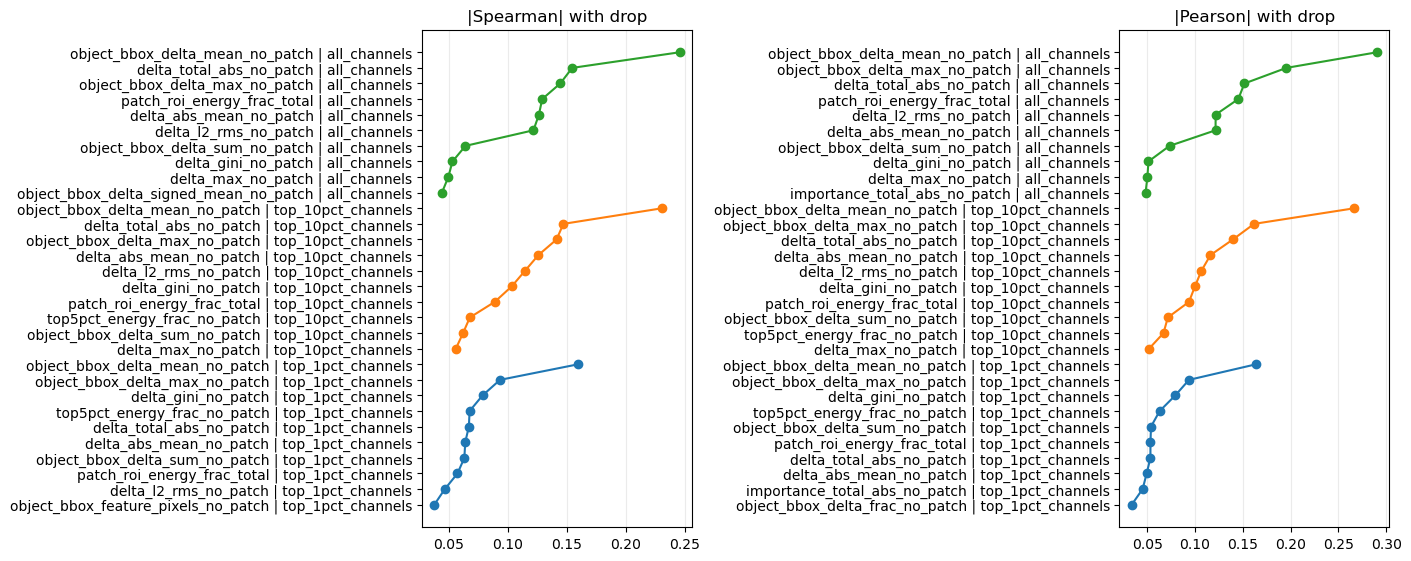

In [14]:
from patch_success_analysis.regression_metrics import regression_similarity_table

patch_excluded_metric_cols = [
    col for col in patch_excluded_df.columns
    if col.endswith("_no_patch") or col == "patch_roi_energy_frac_total"
]

patch_excluded_regression_rows = []
for subset, sub in patch_excluded_df.groupby("subset", sort=False):
    reg = regression_similarity_table(
        sub[["path", "success", "drop", *patch_excluded_metric_cols]],
        target_col="drop",
        metric_cols=patch_excluded_metric_cols,
    )
    reg.insert(0, "subset", subset)
    patch_excluded_regression_rows.append(reg)

patch_excluded_regression_df = pd.concat(patch_excluded_regression_rows, ignore_index=True)
display(
    patch_excluded_regression_df.sort_values(
        ["abs_spearman", "abs_pearson"],
        ascending=False,
    ).head(40)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), constrained_layout=True)
for subset, sub in patch_excluded_regression_df.groupby("subset", sort=False):
    top = sub.sort_values("abs_spearman", ascending=False).head(10).sort_values("abs_spearman")
    axes[0].plot(top["abs_spearman"].to_numpy(), top["metric"].astype(str) + " | " + subset, marker="o", label=subset)
    top = sub.sort_values("abs_pearson", ascending=False).head(10).sort_values("abs_pearson")
    axes[1].plot(top["abs_pearson"].to_numpy(), top["metric"].astype(str) + " | " + subset, marker="o", label=subset)
axes[0].set_title("|Spearman| with drop")
axes[1].set_title("|Pearson| with drop")
for ax in axes:
    ax.grid(axis="x", alpha=0.25)
plt.show()